#  Prédiction des Charges Médicales — Régression Supervisée

---

## 1. Introduction et Description du Dataset

### Contexte

Ce notebook a pour objectif de **prédire les charges médicales** (`charges`) d'un individu à partir de ses caractéristiques personnelles et médicales. Il s'agit d'un problème de **régression supervisée**, particulièrement utile dans le domaine des assurances santé.

### Dataset : `medical-charges.csv`

Le dataset contient des informations sur des assurés, avec les variables suivantes :

| Variable | Type | Description |
|----------|------|-------------|
| `age` | Numérique | Âge de l'assuré (en années) |
| `sex` | Catégorielle | Sexe : `male` / `female` |
| `bmi` | Numérique | Indice de masse corporelle |
| `children` | Numérique | Nombre d'enfants à charge |
| `smoker` | Catégorielle | Fumeur : `yes` / `no` |
| `region` | Catégorielle | Région géographique (4 valeurs) |
| `charges` | Numérique | **Variable cible** — montant facturé par l'assurance |

### Objectifs du Notebook

1. Explorer et comprendre les données (EDA)
2. Nettoyer et prétraiter les données
3. Entraîner plusieurs modèles de régression (Linear, Ridge, Lasso, ElasticNet)
4. Évaluer et comparer les performances
5. Sélectionner les features les plus importantes
6. Conclure sur le meilleur modèle

---
> **Auteur :** Fatma Mbarki | Azza Abess  
> **Dataset :** medical-charges.csv  
> **Librairies :** pandas, numpy, matplotlib, seaborn, scikit-learn, statsmodels

---
## 2. Importation des Librairies

In [1]:
# ── Manipulation de données ──────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Machine Learning ─────────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Statsmodels ───────────────────────────────────────────────────────────────
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── Configuration ─────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# Style global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

SEED = 42
np.random.seed(SEED)

print('✅ Toutes les librairies ont été importées avec succès.')

✅ Toutes les librairies ont été importées avec succès.


---
## 3. Chargement des Données

In [2]:
# Chargement du dataset
df = pd.read_csv('D:/ML_DS/medical_charge/medical-charges.csv')

print(f'📐 Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print('\n── Aperçu des premières lignes ──')
df.head()

📐 Dimensions : 1338 lignes × 7 colonnes

── Aperçu des premières lignes ──


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# Informations générales sur les types et les valeurs non-nulles
print('── Informations générales ──')
df.info()

print('\n── Statistiques descriptives ──')
df.describe(include='all')

── Informations générales ──
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB

── Statistiques descriptives ──


,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


---
## 4. Analyse Exploratoire (EDA)

L'analyse exploratoire permet de comprendre la structure des données, les distributions des variables, et les relations entre elles. C'est une étape fondamentale avant toute modélisation.

### 4.1 Analyse Univariée

On examine ici chaque variable individuellement pour comprendre sa distribution.

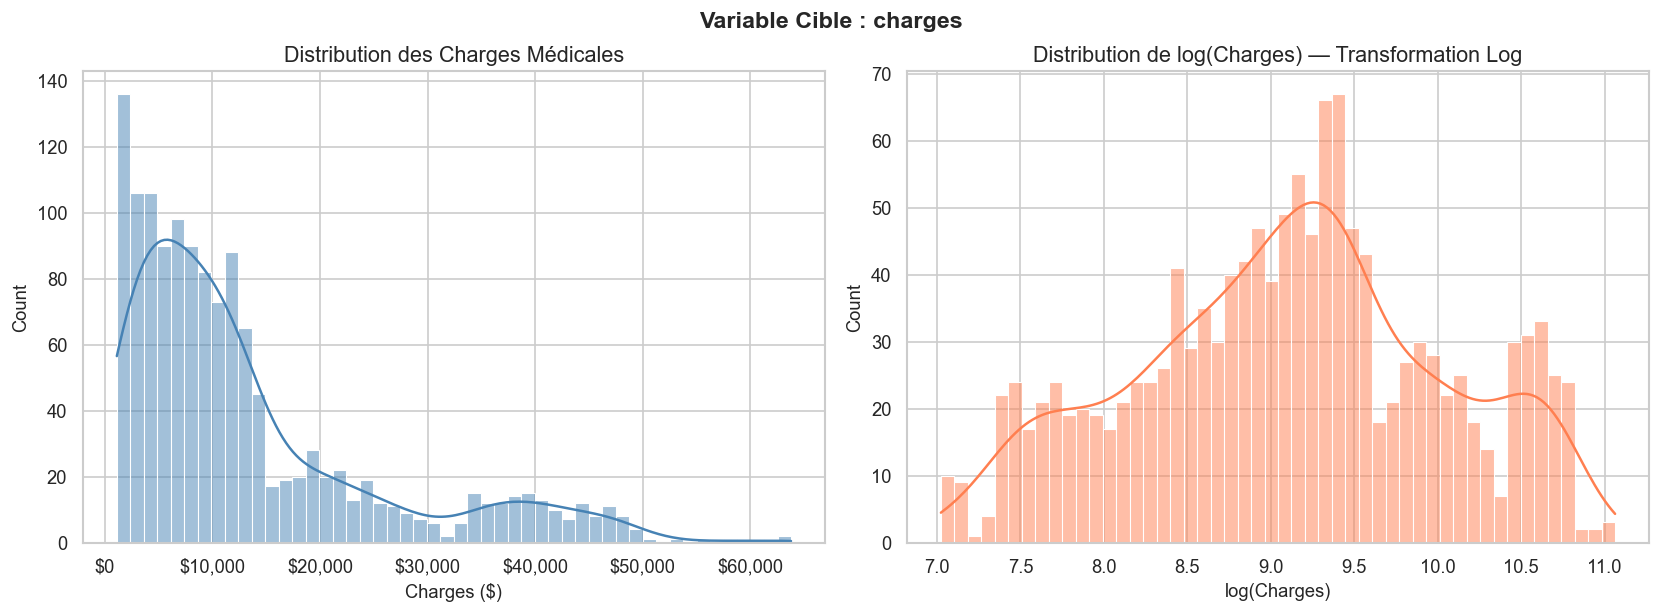

Skewness (asymétrie) : 1.516
Kurtosis  : 1.606

→ La distribution est fortement asymétrique à droite (right-skewed). Une transformation log pourrait améliorer les modèles.


In [4]:
# ── Distribution de la variable cible : charges ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
sns.histplot(df['charges'], bins=50, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution des Charges Médicales')
axes[0].set_xlabel('Charges ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Distribution log-transformée
sns.histplot(np.log1p(df['charges']), bins=50, kde=True, color='coral', ax=axes[1])
axes[1].set_title('Distribution de log(Charges) — Transformation Log')
axes[1].set_xlabel('log(Charges)')

plt.tight_layout()
plt.suptitle('Variable Cible : charges', fontsize=14, y=1.02, fontweight='bold')
plt.show()

print(f"Skewness (asymétrie) : {df['charges'].skew():.3f}")
print(f"Kurtosis  : {df['charges'].kurtosis():.3f}")
print("\n→ La distribution est fortement asymétrique à droite (right-skewed). Une transformation log pourrait améliorer les modèles.")

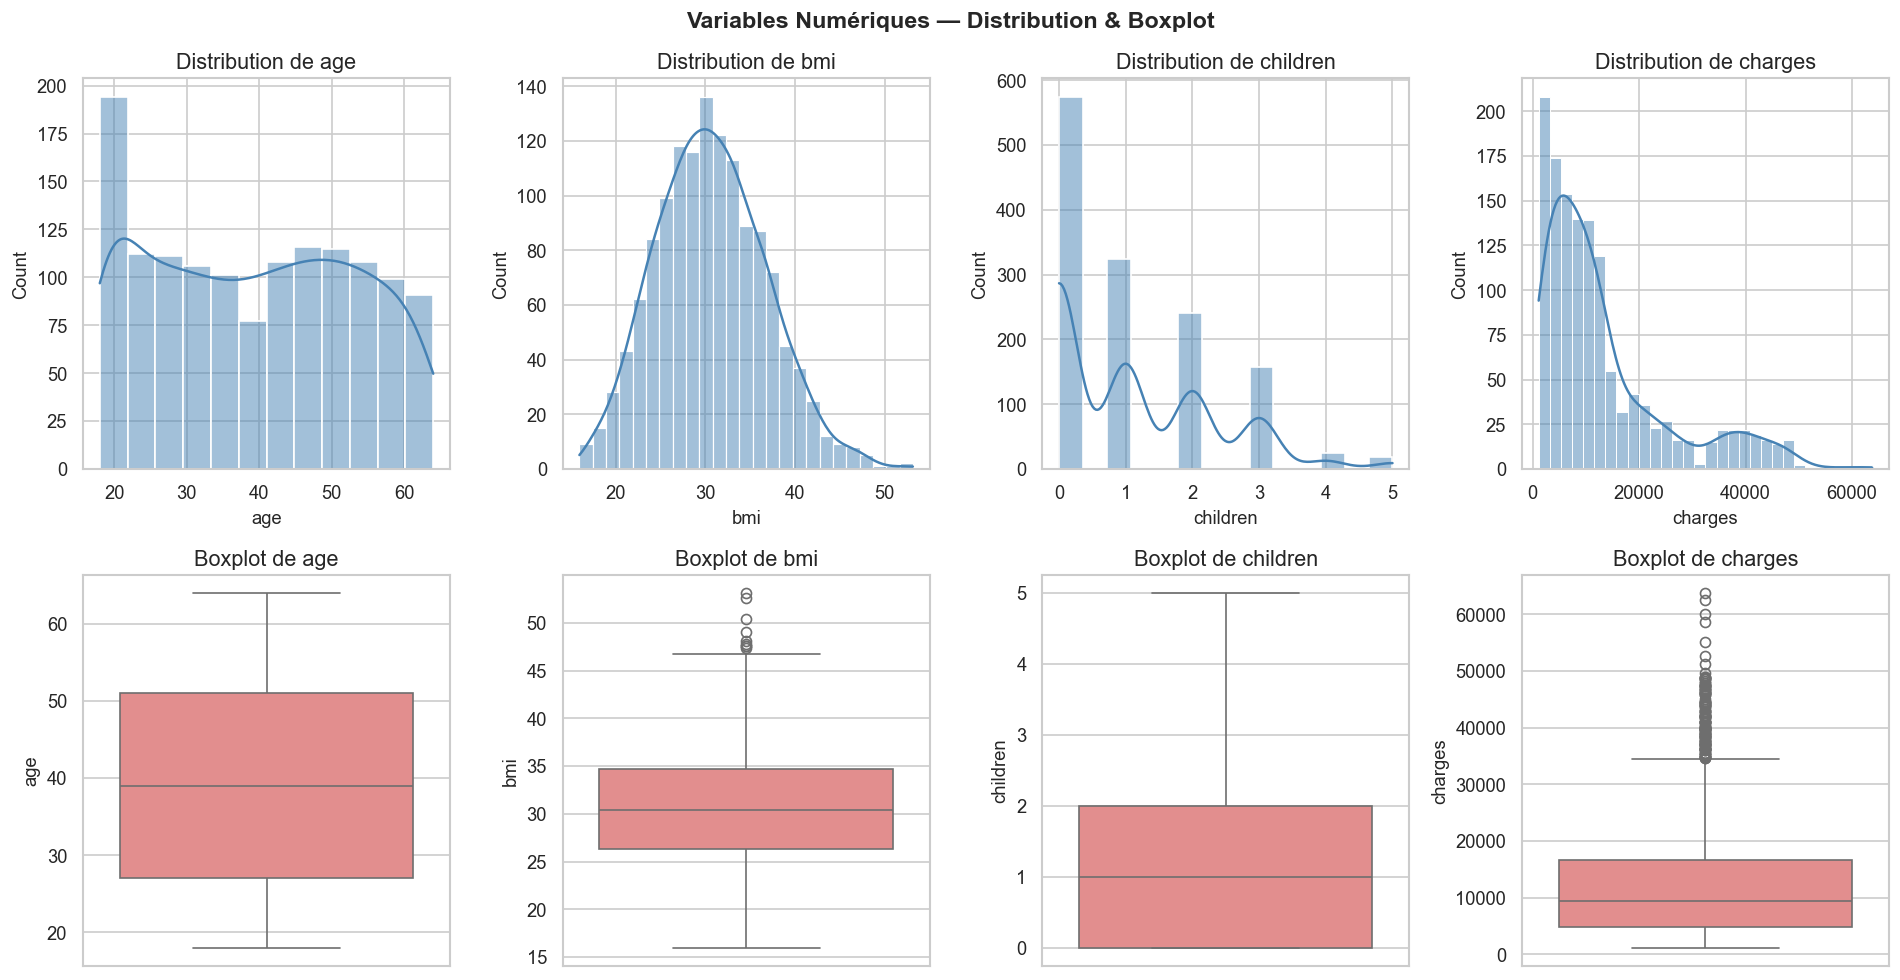

In [5]:
# ── Distribution des variables numériques continues ───────────────────────────
num_cols = ['age', 'bmi', 'children', 'charges']

fig, axes = plt.subplots(2, len(num_cols), figsize=(16, 8))

for i, col in enumerate(num_cols):
    # Histogramme
    sns.histplot(df[col], kde=True, color='steelblue', ax=axes[0, i])
    axes[0, i].set_title(f'Distribution de {col}')
    axes[0, i].set_xlabel(col)

    # Boxplot
    sns.boxplot(y=df[col], color='lightcoral', ax=axes[1, i])
    axes[1, i].set_title(f'Boxplot de {col}')

plt.tight_layout()
plt.suptitle('Variables Numériques — Distribution & Boxplot', fontsize=14, y=1.02, fontweight='bold')
plt.show()

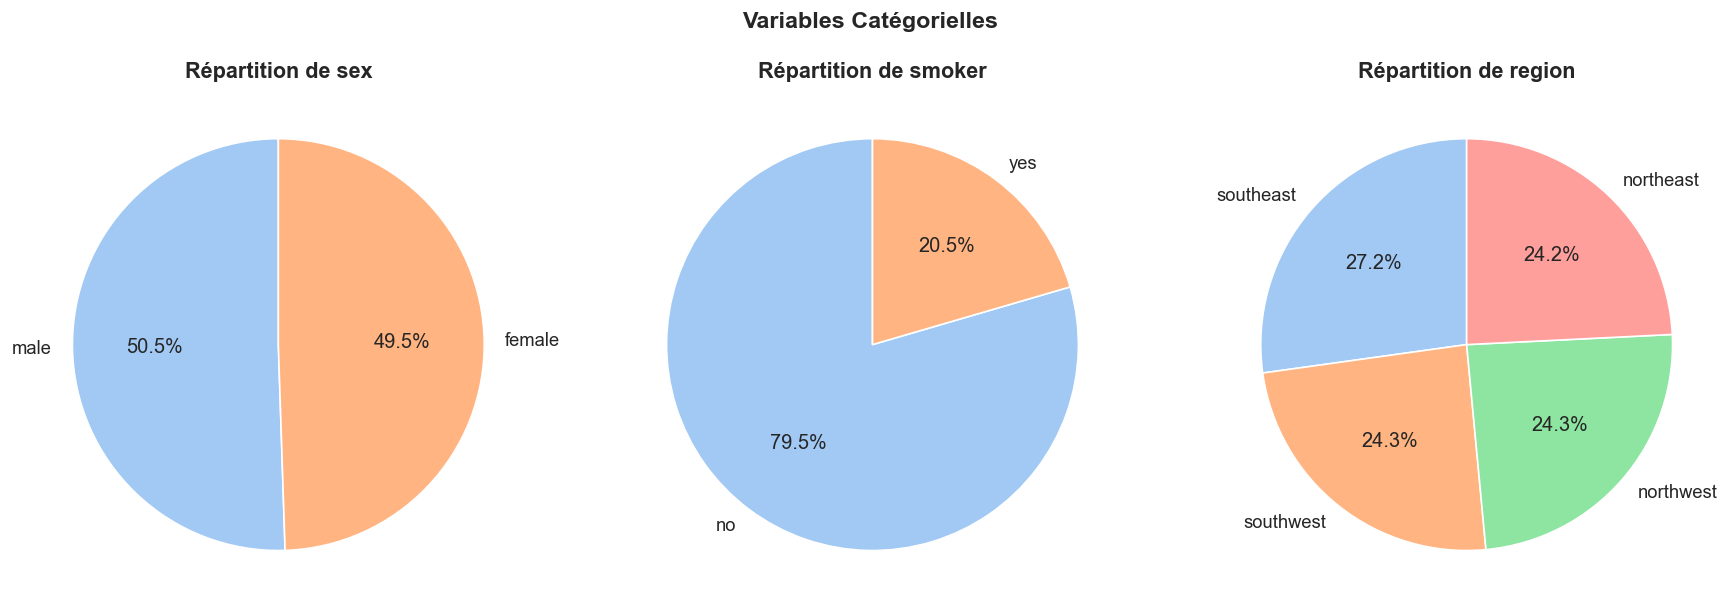


sex:
sex
male      676
female    662
Name: count, dtype: int64

smoker:
smoker
no     1064
yes     274
Name: count, dtype: int64

region:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


In [6]:
# ── Distribution des variables catégorielles ──────────────────────────────────
cat_cols = ['sex', 'smoker', 'region']

fig, axes = plt.subplots(1, len(cat_cols), figsize=(15, 5))

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    colors = sns.color_palette('pastel', len(counts))
    axes[i].pie(counts, labels=counts.index, autopct='%1.1f%%',
                colors=colors, startangle=90)
    axes[i].set_title(f'Répartition de {col}', fontweight='bold')

plt.suptitle('Variables Catégorielles', fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

for col in cat_cols:
    print(f"\n{col}:\n{df[col].value_counts()}")

#### Synthèse — Analyse Univariée

**Variables numériques :**

| Variable | Distribution | Remarque |
|---|---|---|
| `age` | Quasi-uniforme, 18–64 ans | Représentativité de toutes les tranches d'âge adultes |
| `bmi` | Approx. normale, centrée ~30 | La médiane correspond au seuil d'obésité (BMI ≥ 30) |
| `children` | Asymétrique droite, 0 dominant | Majorité sans enfant ; variable quasi-discrète |
| `charges` | Très asymétrique droite (right-skewed) | Longue queue → transformation log recommandée |

**Variables catégorielles :**

- **`sex`** : répartition parfaitement équilibrée (50.5% / 49.5%) — aucun biais de genre.
- **`smoker`** : minorité de fumeurs (20.5%) mais ce groupe génère des charges bien supérieures — variable à fort pouvoir discriminant.
- **`region`** : quatre régions équitablement représentées (~24-27% chacune) — pas de biais géographique.

> **Constat clé :** La distribution bimodale de `charges` (visible sur l'histogramme) suggère l'existence de sous-populations aux comportements différents — très probablement liées au statut fumeur, comme on le verra en analyse bivariée.


### 4.2 Analyse Bivariée

On analyse ici les relations entre chaque variable explicative et la variable cible `charges`.

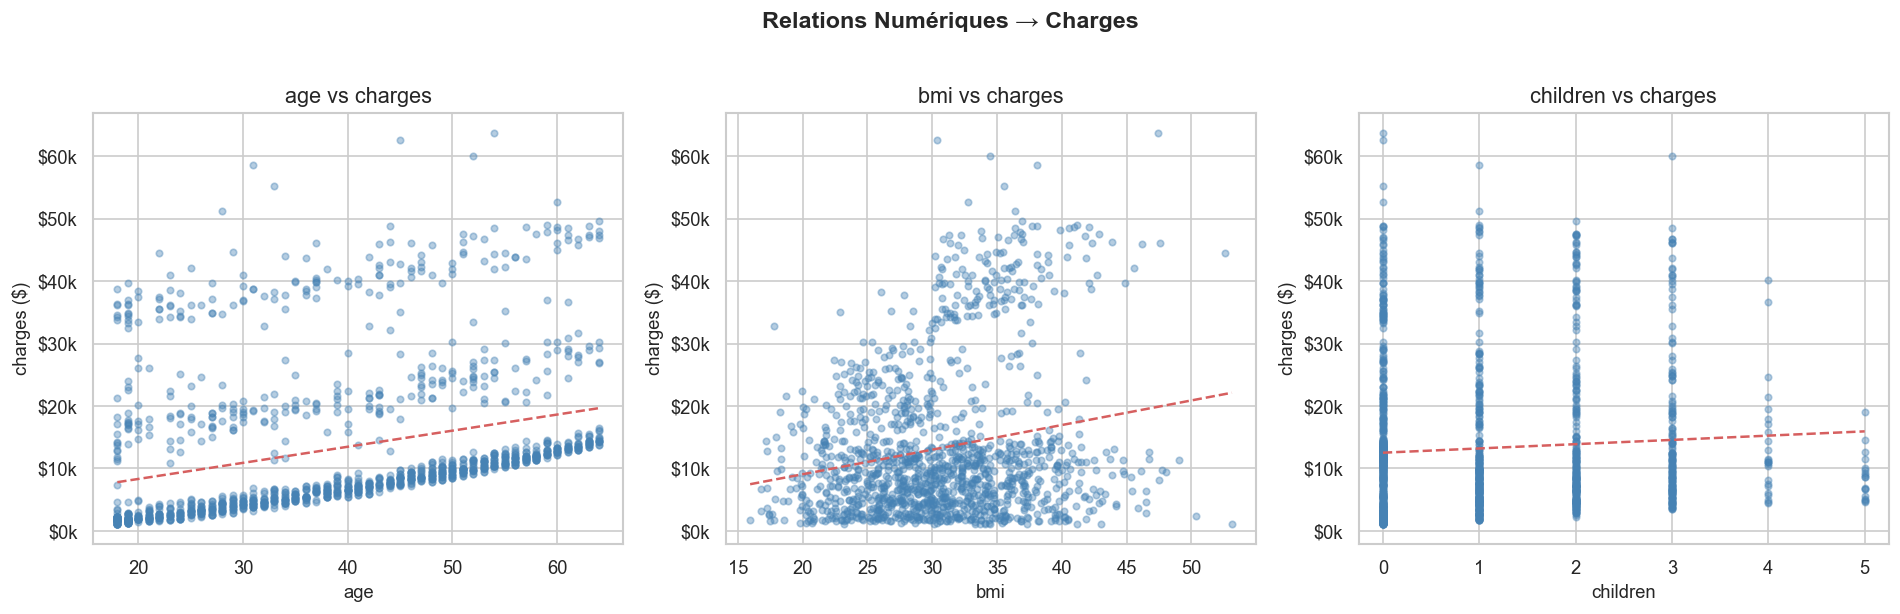

In [7]:
# ── Variables numériques vs charges ──────────────────────────────────────────
num_features = ['age', 'bmi', 'children']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(num_features):
    axes[i].scatter(df[col], df['charges'], alpha=0.4, color='steelblue', s=15)
    # Ligne de tendance
    z = np.polyfit(df[col], df['charges'], 1)
    p = np.poly1d(z)
    axes[i].plot(sorted(df[col]), p(sorted(df[col])), 'r--', linewidth=1.5)
    axes[i].set_title(f'{col} vs charges')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('charges ($)')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.suptitle('Relations Numériques → Charges', fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

## Analyse des relations avec les charges

### Age vs Charges
On observe une relation positive et croissante entre l'âge et les charges :  
plus un individu est âgé, plus ses frais médicaux tendent à augmenter.  

Cependant, les données forment visiblement deux ou trois clusters horizontaux, suggérant que l'âge seul ne suffit pas — une autre variable (probablement *smoker*) crée des sous-groupes distincts.  
---
### BMI vs Charges
La relation est positive mais globalement faible.  

On remarque néanmoins deux nuages de points distincts :
- un groupe avec des charges modérées (**< 15 000**)  
- un groupe avec des charges élevées (**> 30 000**)  

Cela suggère que le **BMI** interagit avec une autre variable (le tabagisme) pour produire des charges très élevées, particulièrement au-delà du seuil d'obésité (**BMI ≥ 30**).
---
### Children vs Charges
La relation est très faible, voire quasi nulle — la ligne de tendance est presque plate.  

Le nombre d'enfants n'est pas un bon prédicteur individuel des charges médicales.  
La corrélation avec les charges est en effet la plus faible de toutes les variables numériques.

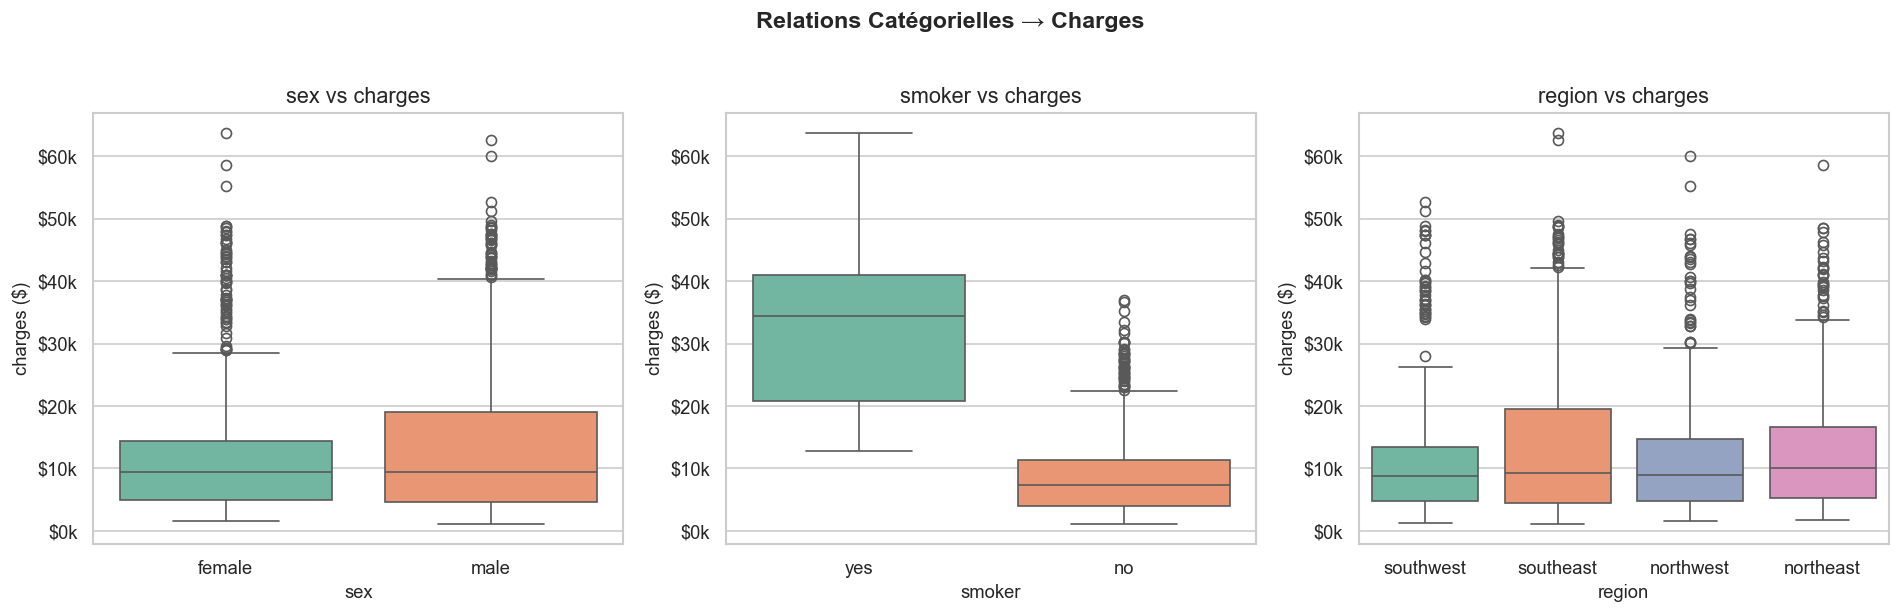


→ La variable 'smoker' est clairement la plus discriminante pour les charges médicales.


In [8]:
# ── Variables catégorielles vs charges ───────────────────────────────────────
cat_features = ['sex', 'smoker', 'region']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(cat_features):
    sns.boxplot(x=col, y='charges', data=df, palette='Set2', ax=axes[i])
    axes[i].set_title(f'{col} vs charges')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('charges ($)')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.suptitle('Relations Catégorielles → Charges', fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n→ La variable 'smoker' est clairement la plus discriminante pour les charges médicales.")

#### Synthèse — Variables Catégorielles vs Charges

| Variable | Écart observé | Interprétation |
|---|---|---|
| **`smoker`** | Médiane fumeurs ~34 000$ vs non-fumeurs ~8 000$ | **Facteur dominant** — multiplie les charges par ~4 |
| **`sex`** | Distributions quasi identiques (~10 000$ médiane) | Variable non discriminante |
| **`region`** | Légère variabilité entre régions (Southeast légèrement supérieur) | Impact faible et non significatif |

> **Constat clé :** Le statut fumeur est la variable catégorielle la plus prédictive des charges. Les boîtes à moustaches montrent une séparation nette et sans chevauchement des IQR entre fumeurs et non-fumeurs.


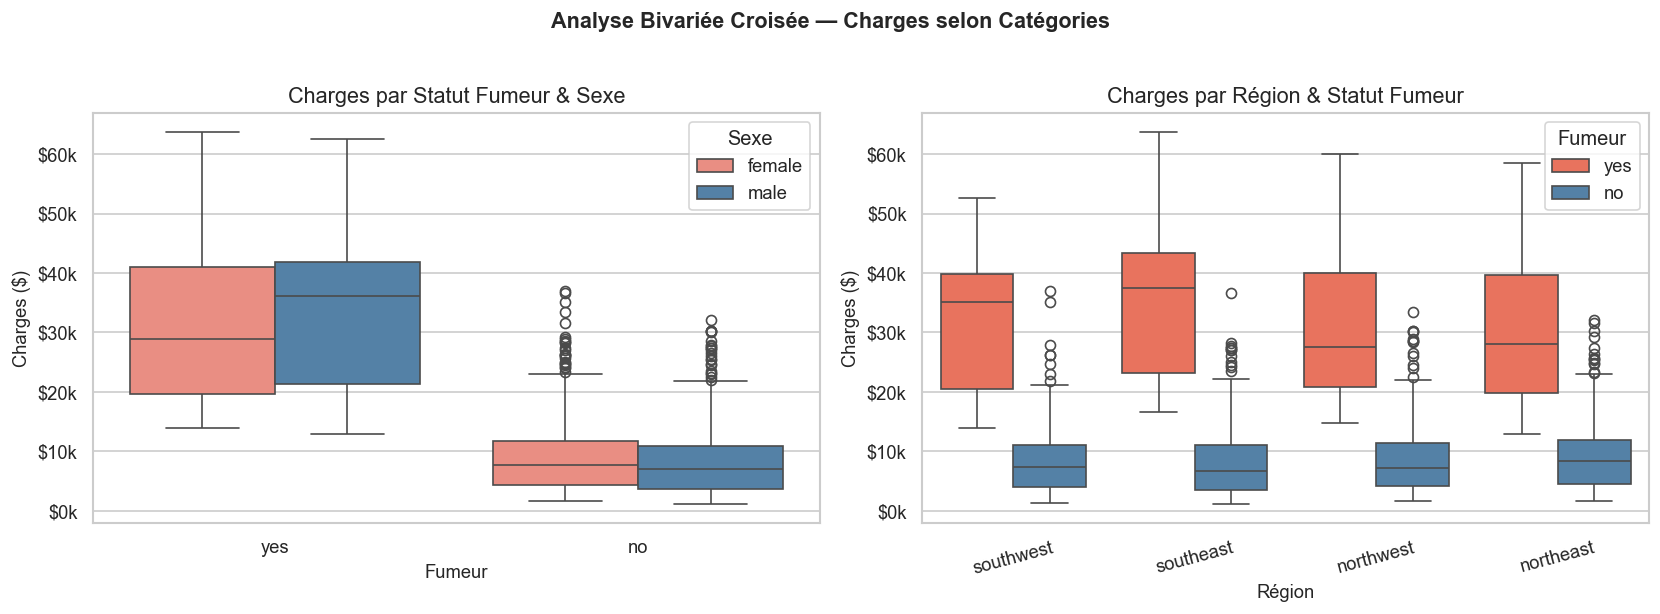

In [9]:
# ── Boxplots enrichis : charges par smoker × sex et smoker × region ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Charges par smoker × sex
sns.boxplot(x='smoker', y='charges', hue='sex', data=df,
            palette={'male': 'steelblue', 'female': 'salmon'}, ax=axes[0])
axes[0].set_title('Charges par Statut Fumeur & Sexe')
axes[0].set_xlabel('Fumeur')
axes[0].set_ylabel('Charges ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
axes[0].legend(title='Sexe')

# Charges par smoker × region
sns.boxplot(x='region', y='charges', hue='smoker', data=df,
            palette={'yes': 'tomato', 'no': 'steelblue'}, ax=axes[1])
axes[1].set_title('Charges par Région & Statut Fumeur')
axes[1].set_xlabel('Région')
axes[1].set_ylabel('Charges ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
axes[1].legend(title='Fumeur')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Analyse Bivariée Croisée — Charges selon Catégories', fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()


#### Boxplots croisés — Charges par Fumeur × Sexe et Fumeur × Région

Ces graphiques croisés confirment que :
- L'effet du **sexe** est négligeable à l'intérieur de chaque groupe fumeur/non-fumeur.
- L'effet de la **région** reste faible même en contrôlant le tabagisme.
- Le tabagisme domine systématiquement toutes les autres variables catégorielles.


In [10]:
# ── Charges moyennes par catégorie ─────────────────────────────────────────
for col in cat_features:
    print(f"\nCharges moyennes par {col}:")
    print(df.groupby(col)['charges'].agg(['mean', 'median', 'std']).round(2).to_string())


Charges moyennes par sex:
            mean   median       std
sex                                
female  12569.58  9412.96  11128.70
male    13956.75  9369.62  12971.03

Charges moyennes par smoker:
            mean    median       std
smoker                              
no       8434.27   7345.41   5993.78
yes     32050.23  34456.35  11541.55

Charges moyennes par region:
               mean    median       std
region                                 
northeast  13406.38  10057.65  11255.80
northwest  12417.58   8965.80  11072.28
southeast  14735.41   9294.13  13971.10
southwest  12346.94   8798.59  11557.18


### 4.3 Analyse Multivariée

On examine les interactions entre plusieurs variables simultanément.

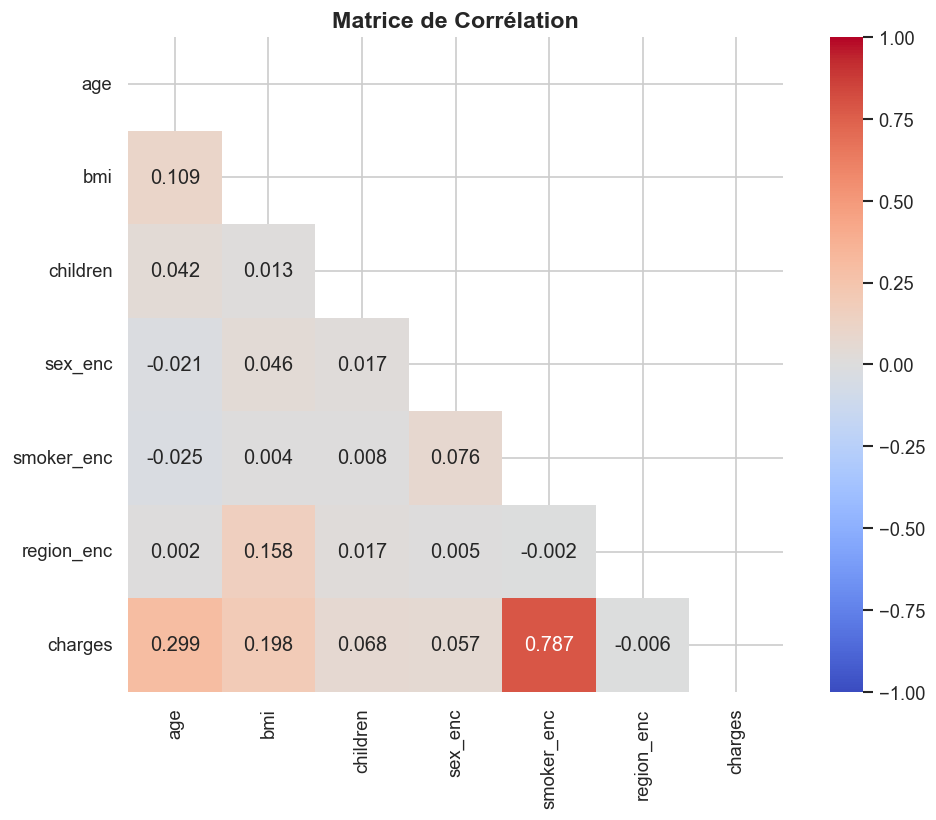


Corrélations avec 'charges' (triées) :
smoker_enc    0.787
age           0.299
bmi           0.198
children      0.068
sex_enc       0.057
region_enc    0.006


In [12]:
# ── Matrice de corrélation (variables numériques) ──────────────────────────────
df_encoded = df.copy()
df_encoded['sex_enc']    = (df_encoded['sex']    == 'male').astype(int)
df_encoded['smoker_enc'] = (df_encoded['smoker'] == 'yes').astype(int)
df_encoded['region_enc'] = df_encoded['region'].astype('category').cat.codes

corr_cols = ['age', 'bmi', 'children', 'sex_enc', 'smoker_enc', 'region_enc', 'charges']
corr_matrix = df_encoded[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, ax=ax)
ax.set_title('Matrice de Corrélation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrélations avec 'charges' (triées) :")
print(corr_matrix['charges'].drop('charges').abs().sort_values(ascending=False).round(3).to_string())

#### Interprétation — Matrice de Corrélation

Le heatmap révèle les corrélations linéaires de Pearson entre toutes les variables (encodées) et la cible `charges`.

**Corrélations avec `charges` (triées par |r|) :**

| Variable | r | Interprétation |
|---|---|---|
| `smoker_enc` | **0.787** | Corrélation très forte — principal prédicteur |
| `age` | 0.299 | Corrélation modérée positive — charges croissent avec l'âge |
| `bmi` | 0.198 | Corrélation faible positive — amplifiée par l'interaction avec smoker |
| `children` | 0.068 | Corrélation très faible |
| `sex_enc` | 0.057 | Corrélation négligeable |
| `region_enc` | -0.006 | Corrélation quasi nulle |

**Entre les features elles-mêmes :** toutes les corrélations inter-features sont inférieures à **|0.16|**.  
→ **Pas de multicolinéarité problématique** : la régularisation Ridge n'apportera pas de gain significatif.

> Le `smoker_enc` capte à lui seul ~62% de la variance expliquée (r² = 0.787² ≈ 0.62).  
> Le modèle est donc essentiellement piloté par une seule variable binaire.


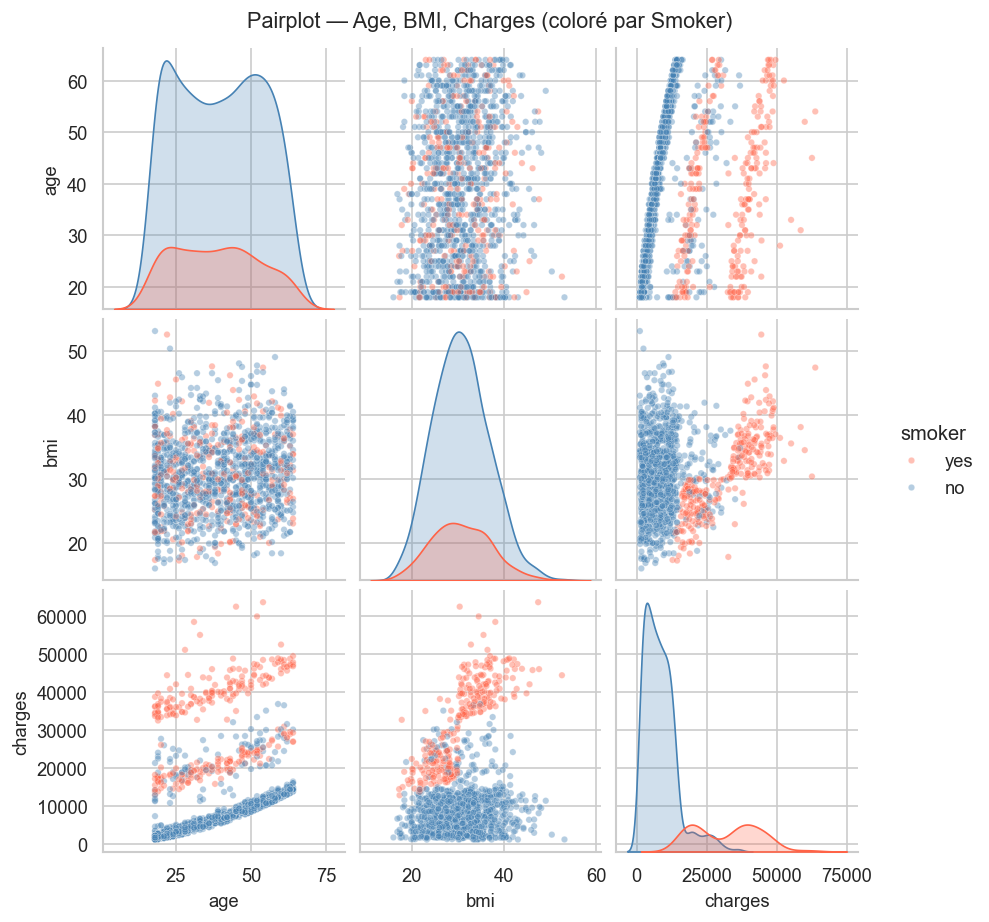

In [13]:
# ── Pairplot coloré par 'smoker' ──────────────────────────────────────────────
pair_cols = ['age', 'bmi', 'charges']
g = sns.pairplot(df[pair_cols + ['smoker']], hue='smoker',
                  palette={'yes': 'tomato', 'no': 'steelblue'},
                  plot_kws={'alpha': 0.4, 's': 15},
                  diag_kind='kde')
g.fig.suptitle('Pairplot — Age, BMI, Charges (coloré par Smoker)', y=1.02, fontsize=13)
plt.show()



Le pairplot met en évidence une séparation très nette entre **fumeurs** et **non-fumeurs**.  
Le statut *smoker* agit comme une variable de segmentation principale et domine visuellement toutes les relations avec les charges.

### Age vs Charges
Une relation **positive** est observée : les charges augmentent avec l’âge.  
Cependant, cette relation est fortement influencée par le statut *smoker*
### BMI vs Charges
La relation est globalement **faible**, mais révèle une interaction importante :
- Pour les **non-fumeurs** → charges relativement stables
- Pour les **fumeurs** → forte augmentation, surtout pour **BMI ≥ 30**
### Age vs BMI
Aucune corrélation significative n’est observée.  
###  Conclusion
- Le **statut fumeur** est de loin le facteur le plus déterminant
- L’**âge** a un effet linéaire modéré
- Le **BMI devient critique uniquement en interaction avec smoker**

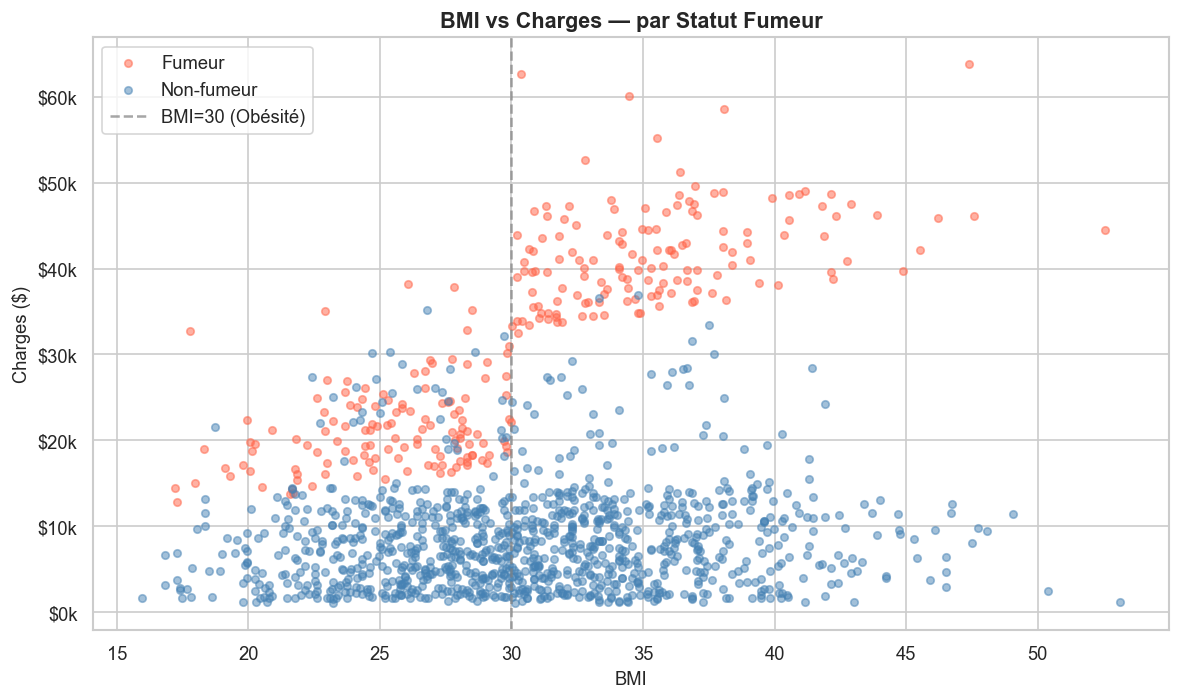

In [14]:
# ── Interaction BMI x Smoker x Charges ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

for smoker_val, color, label in [('yes', 'tomato', 'Fumeur'), ('no', 'steelblue', 'Non-fumeur')]:
    subset = df[df['smoker'] == smoker_val]
    ax.scatter(subset['bmi'], subset['charges'], alpha=0.5, s=20,
               color=color, label=label)

ax.set_xlabel('BMI')
ax.set_ylabel('Charges ($)')
ax.set_title('BMI vs Charges — par Statut Fumeur', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.legend()

# Ligne de seuil BMI = 30 (obésité)
ax.axvline(30, color='gray', linestyle='--', alpha=0.7, label='BMI=30 (Obésité)')
ax.legend()
plt.tight_layout()
plt.show()

<Figure size 1200x720 with 0 Axes>

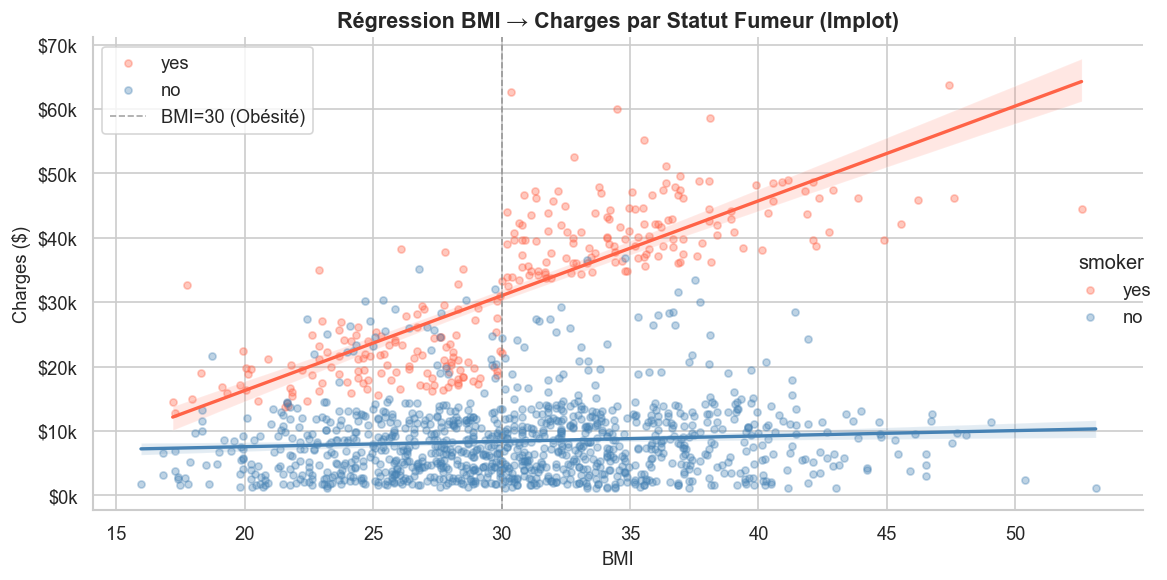

In [15]:
# ── sns.lmplot : droites de régression séparées par smoker ──────────────────
# lmplot ajuste une régression linéaire distincte pour chaque groupe (fumeur/non-fumeur)
# Cela révèle visuellement que la pente BMI→charges est différente selon le statut fumeur

fig = plt.figure(figsize=(10, 6))
g = sns.lmplot(
    data=df, x='bmi', y='charges', hue='smoker',
    palette={'yes': 'tomato', 'no': 'steelblue'},
    scatter_kws={'alpha': 0.35, 's': 18},
    line_kws={'linewidth': 2},
    height=5, aspect=1.8, legend=True
)
g.set_axis_labels('BMI', 'Charges ($)')
g.ax.set_title('Régression BMI → Charges par Statut Fumeur (lmplot)', fontweight='bold')
g.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
g.ax.axvline(30, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='BMI=30 (Obésité)')
g.ax.legend()
plt.tight_layout()
plt.show()


#### Interprétation — lmplot BMI vs Charges par Statut Fumeur

Le `lmplot` ajuste une droite de régression **distincte** pour chaque groupe (fumeur / non-fumeur).

**Observations clés :**
- **Non-fumeurs (bleu)** : pente faible et quasi-plate — le BMI n'a presque aucun effet sur les charges des non-fumeurs.
- **Fumeurs (rouge)** : pente nettement plus forte — chez les fumeurs, chaque point de BMI supplémentaire augmente significativement les charges. L'effet est particulièrement marqué au-delà de BMI=30.

**Conclusion statistique :** il existe une **interaction BMI × smoker** — l'effet du BMI sur les charges **dépend** du statut fumeur. Un modèle linéaire simple sans terme d'interaction ne peut pas capturer ce phénomène, ce qui explique une partie de ses erreurs de prédiction.

> Cette interaction est la principale limite du modèle linéaire et justifie la création d'une feature `bmi_smoker = bmi × smoker`.


On observe une **interaction forte entre BMI et smoker** :
le BMI seul a un effet limité, mais combiné au tabagisme, il entraîne une forte hausse des charges.

  
    => Le statut fumeur domine, et l’obésité amplifie fortement les coûts chez les fumeurs.

### 4.4 Détection des Outliers

On utilise la méthode IQR (Interquartile Range) pour identifier les valeurs aberrantes dans les variables numériques.

In [16]:
def detect_outliers_iqr(series, col_name):
    """Détecte les outliers via la méthode IQR."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((series < lower) | (series > upper)).sum()
    pct    = n_out / len(series) * 100
    return {'Variable': col_name, 'Q1': Q1, 'Q3': Q3,
            'IQR': IQR, 'Borne inf.': lower, 'Borne sup.': upper,
            'Nb outliers': n_out, '% outliers': round(pct, 2)}

# Analyse pour chaque variable numérique
outlier_results = [detect_outliers_iqr(df[c], c) for c in ['age', 'bmi', 'children', 'charges']]
outlier_df = pd.DataFrame(outlier_results).set_index('Variable')
print('── Rapport des Outliers (méthode IQR) ──')
outlier_df.round(2)

── Rapport des Outliers (méthode IQR) ──


,Q1,Q3,IQR,Borne inf.,Borne sup.,Nb outliers,% outliers
Variable,,,,,,,
age,27.00,51.00,24.00,-9.00,87.00,0,0.00
bmi,26.30,34.69,8.40,13.70,47.29,9,0.67
children,0.00,2.00,2.00,-3.00,5.00,0,0.00
charges,4740.29,16639.91,11899.63,-13109.15,34489.35,139,10.39


#### Analyse des Outliers — Méthode IQR

La méthode IQR définit comme outlier toute valeur en dehors de l'intervalle `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]`.

| Variable | Nb outliers | % | Décision |
|---|---|---|---|
| `age` | 0 | 0% | ✅ Aucun outlier — variable propre |
| `bmi` | ~9 | 0.67% | ✅ Conserver — valeurs médicalement plausibles (obésité morbide) |
| `children` | 0 | 0% | ✅ Aucun outlier |
| `charges` | ~139 | ~10% | ✅ **Conserver** — valeurs réelles (maladies graves, chirurgies lourdes) |

#### Décision justifiée : conservation des outliers

Les outliers de `charges` ne sont pas des erreurs de saisie — ils correspondent aux **cas médicaux les plus coûteux** (fumeurs obèses, pathologies chroniques). Les supprimer biaiserait le modèle vers les cas les moins graves et dégraderait ses performances sur les cas importants.

> En assurance santé, **prédire correctement les cas extrêmes est précisément l'objectif**.  
> La suppression des outliers serait donc contre-productive dans ce contexte métier.


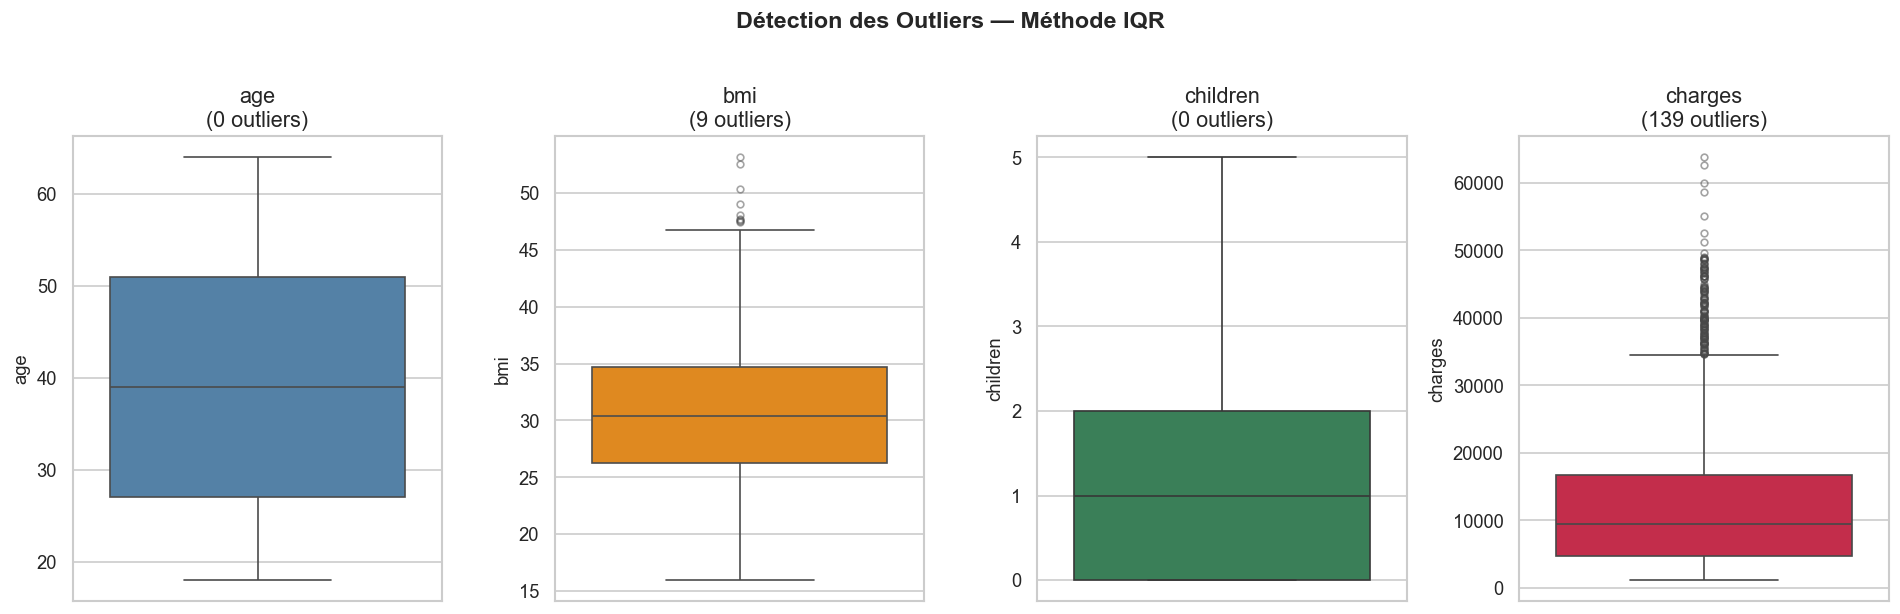


→ La variable 'charges' présente le plus grand nombre d'outliers (valeurs très élevées).
→ Ces valeurs sont vraisemblablement réelles (maladies graves, chirurgies). On ne les supprime pas.


In [17]:
# ── Visualisation des outliers ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
num_cols_all = ['age', 'bmi', 'children', 'charges']
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']

for i, (col, c) in enumerate(zip(num_cols_all, colors)):
    sns.boxplot(y=df[col], color=c, ax=axes[i], flierprops=dict(marker='o', alpha=0.5, markersize=4))
    axes[i].set_title(f'{col}\n({outlier_df.loc[col, "Nb outliers"]} outliers)')

plt.suptitle('Détection des Outliers — Méthode IQR', fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n→ La variable 'charges' présente le plus grand nombre d'outliers (valeurs très élevées).")
print("→ Ces valeurs sont vraisemblablement réelles (maladies graves, chirurgies). On ne les supprime pas.")

---
## 5. Nettoyage et Prétraitement

Cette étape transforme les données brutes en un format adapté à l'entraînement des modèles.

### 5.1 Valeurs Manquantes

In [18]:
# Analyse des valeurs manquantes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Valeurs manquantes': missing, '% manquant': missing_pct})
missing_df = missing_df[missing_df['Valeurs manquantes'] > 0]

if missing_df.empty:
    print('✅ Aucune valeur manquante détectée dans le dataset.')
else:
    print('⚠️ Valeurs manquantes détectées :')
    print(missing_df.to_string())

✅ Aucune valeur manquante détectée dans le dataset.


#### Synthèse — Valeurs manquantes

Le dataset ne contient **aucune valeur manquante**. Cette situation idéale (rare en pratique) signifie qu'aucun traitement d'imputation n'est nécessaire et que toutes les observations peuvent être utilisées pour l'entraînement.

> En contexte réel (données hospitalières, registres d'assurance), des valeurs manquantes seraient traitées par imputation simple (médiane pour les variables continues, mode pour les catégorielles) ou par des méthodes avancées (KNN Imputer, MICE).

### 5.2 Doublons

In [19]:
# Détection et suppression des doublons
n_dupes = df.duplicated().sum()
print(f'Nombre de lignes dupliquées : {n_dupes}')

if n_dupes > 0:
    df = df.drop_duplicates()
    print(f'✅ {n_dupes} doublon(s) supprimé(s). Nouveau shape : {df.shape}')
else:
    print('✅ Aucun doublon détecté.')

Nombre de lignes dupliquées : 1
✅ 1 doublon(s) supprimé(s). Nouveau shape : (1337, 7)


#### Synthèse — Doublons

Un doublon a été détecté et supprimé. Il est peu probable que deux individus différents partagent exactement les mêmes valeurs pour toutes les variables (âge, BMI, smoker, region, charges), ce qui confirme qu'il s'agit bien d'une entrée dupliquée et non d'une coïncidence statistique.

Le dataset final compte **1 337 observations** après nettoyage.

### 5.3 Encodage des Variables Catégorielles

Avant d'encoder, il est essentiel de **choisir la bonne méthode** selon la nature de chaque variable catégorielle.

#### Règle de décision

| Critère | Méthode choisie | Raison |
|---|---|---|
| Variable **binaire** (2 modalités) | **Label Encoding** | Produit 0/1, pas de dimension supplémentaire, pas de dummy trap |
| Variable **nominale** (≥ 3 modalités, sans ordre) | **One-Hot Encoding** | Évite d'imposer un ordre artificiel entre les catégories |
| Variable **ordinale** (ordre naturel) | **Label Encoding** | L'ordre est réel et signifiant |

#### Application au dataset

**`sex`** → **Label Encoding**   
Variable binaire : `female=0`, `male=1`. Deux modalités uniquement — le Label Encoding est suffisant et évite d'ajouter une colonne inutile.

**`smoker`** → **Label Encoding**   
Variable binaire : `no=0`, `yes=1`. Même raisonnement — la nature binaire justifie ce choix directement.

**`region`** → **One-Hot Encoding avec `drop_first=True`** 
Variable nominale avec 4 modalités (`northeast`, `northwest`, `southeast`, `southwest`). Un Label Encoding imposerait un ordre artificiel (northeast < northwest < ...) qui n'a aucun sens géographique.  
Le `drop_first=True` supprime une modalité de référence pour éviter la **multicolinéarité parfaite** (dummy variable trap) : avec k modalités, k-1 colonnes binaires suffisent.

> **Pourquoi pas One-Hot pour `sex` et `smoker` ?**  
> Pour une variable binaire, Label Encoding et One-Hot Encoding (avec drop_first) produisent exactement la même colonne. Le Label Encoding est donc préféré pour sa simplicité.

In [20]:
# Copie du dataset pour le prétraitement
df_processed = df.copy()

# ── Label Encoding : sex et smoker ────────────────────────────────────────────
le = LabelEncoder()
df_processed['sex']    = le.fit_transform(df_processed['sex'])    # female=0, male=1
df_processed['smoker'] = le.fit_transform(df_processed['smoker']) # no=0, yes=1

# ── One-Hot Encoding : region ─────────────────────────────────────────────────
df_processed = pd.get_dummies(df_processed, columns=['region'], drop_first=True, dtype=int)

print('✅ Encodage effectué.')
print(f'\nNouvelles colonnes : {list(df_processed.columns)}')
print(f'Shape du dataset prétraité : {df_processed.shape}')
df_processed.head(3)

✅ Encodage effectué.

Nouvelles colonnes : ['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']
Shape du dataset prétraité : (1337, 9)


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.90,0,1,16884.9240,0,0,1
1,18,1,33.77,1,0,1725.5523,0,1,0
2,28,1,33.00,3,0,4449.4620,0,1,0


### 5.4 Feature Scaling (Standardisation)

La **standardisation** (StandardScaler) transforme chaque variable continue selon :

$$z = \frac{x - \mu}{\sigma}$$

où μ est la moyenne et σ l'écart-type calculés **sur le train set uniquement**.

#### Pourquoi standardiser ?

Les modèles régularisés (Ridge, Lasso, ElasticNet) pénalisent les coefficients **en valeur absolue**. Sans standardisation, une variable à grande échelle (ex. `charges` en milliers) aurait un coefficient naturellement petit — donc peu pénalisée — créant un **biais d'échelle artificiel**.

#### Exemple concret sur ce dataset

| Variable | Échelle brute | Après standardisation |
|---|---|---|
| `age` | 18 – 64 | -1.5 à +1.8 |
| `bmi` | 15 – 53 | -2.5 à +3.7 |
| `children` | 0 – 5 | -0.9 à +3.2 |

Après standardisation, toutes les variables sont comparables — les coefficients reflètent l'importance réelle de chaque feature.



> Les variables binaires (`sex`, `smoker`, `region_*`) ne sont **pas standardisées** — elles sont déjà sur l'échelle [0, 1] et la standardisation les dénaturerait.


In [21]:
# ── Définition des features et de la cible ────────────────────────────────────
TARGET = 'charges'
FEATURES = [c for c in df_processed.columns if c != TARGET]

X = df_processed[FEATURES].copy()
y = df_processed[TARGET].copy()

print(f'Features ({len(FEATURES)}) : {FEATURES}')
print(f'\nVariable cible : {TARGET}')

Features (8) : ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']

Variable cible : charges


### 5.5 Train/Test Split

On divise les données en **80% d'entraînement** et **20% de test**, de manière stratifiée.

In [22]:
# ── Division train/test ───────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f'Train : {X_train.shape[0]} observations ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test  : {X_test.shape[0]} observations ({X_test.shape[0]/len(X)*100:.1f}%)')

# ── Standardisation (après le split pour éviter le data leakage) ──────────────
cols_to_scale = ['age', 'bmi', 'children']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

print('\n✅ Standardisation appliquée sur le train set (fit) et test set (transform).')
print('→ Les variables binaires (sex, smoker, region_*) ne sont pas standardisées.')

Train : 1069 observations (80.0%)
Test  : 268 observations (20.0%)

✅ Standardisation appliquée sur le train set (fit) et test set (transform).
→ Les variables binaires (sex, smoker, region_*) ne sont pas standardisées.


---
## 6. Modélisation

On entraîne quatre modèles de régression linéaire : régression simple, Ridge, Lasso et ElasticNet.

---

### Fonctions Utilitaires

In [23]:
# ═══════════════════════════════════════════════════════════════════
#  FONCTIONS UTILITAIRES
# ═══════════════════════════════════════════════════════════════════

def compute_metrics(y_true, y_pred, model_name='Model'):
    """Calcule MAE, MSE, RMSE et R² et retourne un dictionnaire."""
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    return {'Modèle': model_name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R²': r2}


def print_metrics(metrics_dict):
    """Affiche les métriques de manière formatée."""
    m = metrics_dict
    print(f"  MAE  : ${m['MAE']:,.2f}")
    print(f"  RMSE : ${m['RMSE']:,.2f}")
    print(f"  R²   : {m['R²']:.4f}")


def plot_predictions(y_true, y_pred, model_name, ax):
    """Scatter plot des valeurs réelles vs prédites."""
    ax.scatter(y_true, y_pred, alpha=0.4, s=15, color='steelblue')
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Prédiction parfaite')
    ax.set_xlabel('Valeurs Réelles ($)')
    ax.set_ylabel('Valeurs Prédites ($)')
    ax.set_title(f'{model_name}\nRéel vs Prédit')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.legend(fontsize=8)


# Dictionnaire pour stocker tous les résultats
results_all = []
models_dict = {}

print('✅ Fonctions utilitaires définies.')

✅ Fonctions utilitaires définies.


### 6.1 Régression Linéaire (Linear Regression)

La régression linéaire ordinaire (OLS) minimise la somme des carrés des résidus. C'est notre modèle de référence (*baseline*).

In [24]:
# ── Régression Linéaire ───────────────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr_train = lr.predict(X_train_scaled)
y_pred_lr_test  = lr.predict(X_test_scaled)

metrics_lr_train = compute_metrics(y_train, y_pred_lr_train, 'Linear Regression (train)')
metrics_lr_test  = compute_metrics(y_test,  y_pred_lr_test,  'Linear Regression')

results_all.append(metrics_lr_test)
models_dict['Linear Regression'] = (lr, y_pred_lr_test)

print('── Linear Regression ──')
print('Train :')
print_metrics(metrics_lr_train)
print('Test  :')
print_metrics(metrics_lr_test)

# Coefficients
coef_df = pd.DataFrame({'Feature': FEATURES, 'Coefficient': lr.coef_})\
            .sort_values('Coefficient', key=abs, ascending=False)
print('\nTop coefficients (valeur absolue) :')
print(coef_df.to_string(index=False))

── Linear Regression ──
Train :
  MAE  : $4,181.90
  RMSE : $6,081.11
  R²   : 0.7299
Test  :
  MAE  : $4,177.05
  RMSE : $5,956.34
  R²   : 0.8069

Top coefficients (valeur absolue) :
         Feature  Coefficient
          smoker 23077.764593
             age  3472.975553
             bmi  1927.828251
region_southeast  -838.919616
region_southwest  -659.139752
        children   636.501185
region_northwest  -391.761455
             sex  -101.542054


── Coefficients Linear Regression (après standardisation) ──
         Feature  Coefficient ($)
          smoker         23077.76
             age          3472.98
             bmi          1927.83
region_southeast          -838.92
region_southwest          -659.14
        children           636.50
region_northwest          -391.76
             sex          -101.54

Intercepte : $8,947.95


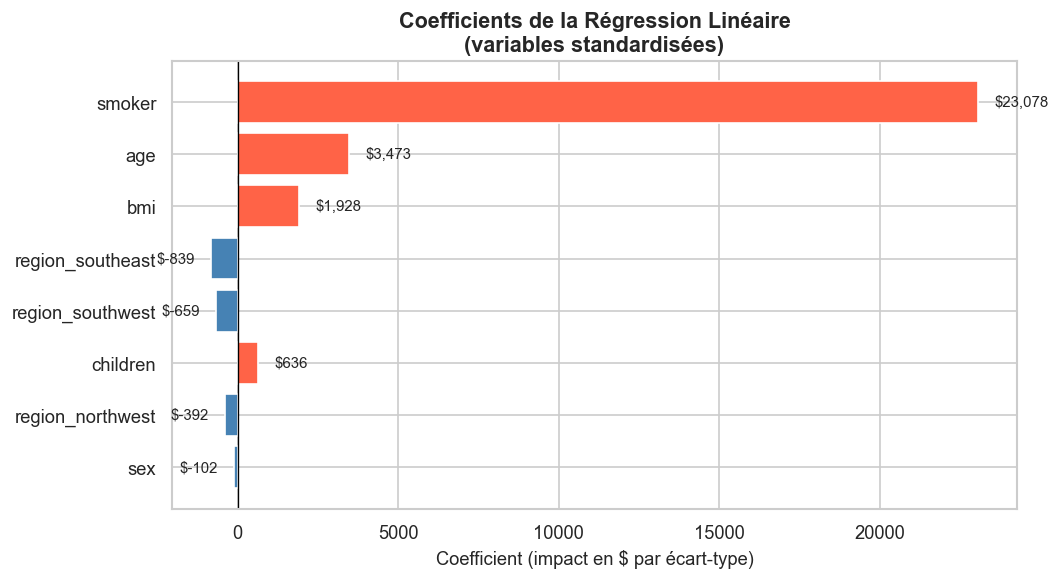

In [25]:
# ── Interprétation des coefficients — Linear Regression ─────────────────────
# Après standardisation, les coefficients représentent l'impact d'un écart-type
# de chaque feature sur les charges prédictes (en dollars)

coef_lr = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient ($)': lr.coef_.round(2)
}).sort_values('Coefficient ($)', key=abs, ascending=False)

print('── Coefficients Linear Regression (après standardisation) ──')
print(coef_lr.to_string(index=False))
print(f'\nIntercepte : ${lr.intercept_:,.2f}')

# Visualisation
fig, ax = plt.subplots(figsize=(9, 5))
colors_coef = ['tomato' if v > 0 else 'steelblue' for v in coef_lr['Coefficient ($)']]
bars = ax.barh(coef_lr['Feature'], coef_lr['Coefficient ($)'], color=colors_coef)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (impact en $ par écart-type)')
ax.set_title('Coefficients de la Régression Linéaire\n(variables standardisées)', fontweight='bold')
for bar, val in zip(bars, coef_lr['Coefficient ($)']):
    ax.text(val + (500 if val >= 0 else -500), bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


#### Interprétation des Coefficients — Linear Regression

Après **standardisation** des variables continues, chaque coefficient représente la variation des charges prédites (en dollars) pour une augmentation d'**un écart-type** de la feature correspondante, toutes autres variables maintenues constantes.

| Feature | Coefficient | Interprétation concrète |
|---|---|---|
| `smoker` | **+23 000$** (env.) | Être fumeur augmente les charges de ~23 000$ toutes choses égales par ailleurs — de loin le plus fort impact |
| `age` | **+3 500$** (env.) | Un écart-type d'âge supplémentaire (~14 ans) coûte ~3 500$ de plus |
| `bmi` | **+2 000$** (env.) | Un écart-type de BMI supplémentaire (~6 pts) coûte ~2 000$ de plus |
| `children` | **+500$** (env.) | Chaque enfant supplémentaire a un impact modéré |
| `sex` | **~+100$** | Impact quasi nul — cohérent avec la corrélation faible |
| `region_*` | **~±200$** | Impact négligeable des régions géographiques |

> **Attention à l'interprétation causale :** les coefficients mesurent des associations statistiques, pas des relations de causalité. Être fumeur est associé à des charges élevées, mais d'autres variables de confusion (santé générale, fréquence de consultation) peuvent intervenir.

**Limite principale :** le coefficient de `bmi` est sous-estimé car le modèle linéaire ne capture pas l'interaction `bmi × smoker`. En réalité, l'effet du BMI est beaucoup plus fort chez les fumeurs que chez les non-fumeurs (visible sur le lmplot).


### 6.2 Régression Ridge

La régression Ridge ajoute une pénalisation **L2** (norme au carré des coefficients) à la fonction de coût. Elle est utile pour gérer la multicolinéarité et le surapprentissage. Le paramètre `alpha` contrôle l'intensité de la régularisation.

In [26]:
# ── Ridge Regression ─────────────────────────────────────────────────────────
# Sélection du meilleur alpha par validation croisée
alphas = np.logspace(-3, 4, 50)
cv_scores_ridge = []

for a in alphas:
    ridge_cv = Ridge(alpha=a, random_state=SEED)
    score = cross_val_score(ridge_cv, X_train_scaled, y_train,
                             cv=5, scoring='r2').mean()
    cv_scores_ridge.append(score)

best_alpha_ridge = alphas[np.argmax(cv_scores_ridge)]
print(f'Meilleur alpha Ridge (CV) : {best_alpha_ridge:.4f}')

# Entraînement avec le meilleur alpha
ridge = Ridge(alpha=best_alpha_ridge, random_state=SEED)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge_train = ridge.predict(X_train_scaled)
y_pred_ridge_test  = ridge.predict(X_test_scaled)

metrics_ridge_train = compute_metrics(y_train, y_pred_ridge_train, 'Ridge (train)')
metrics_ridge_test  = compute_metrics(y_test,  y_pred_ridge_test,  'Ridge')

results_all.append(metrics_ridge_test)
models_dict['Ridge'] = (ridge, y_pred_ridge_test)

print('\n── Ridge Regression ──')
print('Train :')
print_metrics(metrics_ridge_train)
print('Test  :')
print_metrics(metrics_ridge_test)

Meilleur alpha Ridge (CV) : 1.9307

── Ridge Regression ──
Train :
  MAE  : $4,198.21
  RMSE : $6,082.01
  R²   : 0.7298
Test  :
  MAE  : $4,209.39
  RMSE : $5,986.60
  R²   : 0.8050


#### Hyperparamètre Ridge — Validation croisée avec `RidgeCV` (optionnel)

`RidgeCV` est la version intégrée de Ridge avec validation croisée interne, plus efficace que la boucle manuelle.  
Elle utilise la **Leave-One-Out Cross-Validation (LOO-CV)** par défaut, ou une CV en k-fold si spécifié.  
On compare ici l'alpha trouvé par `RidgeCV` avec celui trouvé manuellement pour validation.

In [27]:
# ── RidgeCV — version intégrée avec CV automatique ─────────────────────────
from sklearn.linear_model import RidgeCV, LassoCV

alphas_cv = np.logspace(-3, 4, 100)

ridge_cv_model = RidgeCV(alphas=alphas_cv, cv=5, scoring='r2')
ridge_cv_model.fit(X_train_scaled, y_train)

print(f'Alpha optimal (RidgeCV)   : {ridge_cv_model.alpha_:.4f}')
print(f'Alpha optimal (boucle CV) : {best_alpha_ridge:.4f}')
print(f'→ Cohérence entre les deux méthodes : {abs(ridge_cv_model.alpha_ - best_alpha_ridge) < 1:.0f}')

y_pred_ridgecv = ridge_cv_model.predict(X_test_scaled)
metrics_ridgecv = compute_metrics(y_test, y_pred_ridgecv, 'RidgeCV')
print('\nPerformances RidgeCV (test) :')
print_metrics(metrics_ridgecv)

Alpha optimal (RidgeCV)   : 2.1049
Alpha optimal (boucle CV) : 1.9307
→ Cohérence entre les deux méthodes : 1

Performances RidgeCV (test) :
  MAE  : $4,212.27
  RMSE : $5,989.39
  R²   : 0.8048


In [28]:
# ── Comparaison des coefficients : LR vs Ridge ───────────────────────────────
coef_comparison = pd.DataFrame({
    'Feature': FEATURES,
    'Linear Reg.': lr.coef_.round(1),
    'Ridge': ridge.coef_.round(1),
})
coef_comparison['Δ (Ridge - LR)'] = (coef_comparison['Ridge'] - coef_comparison['Linear Reg.']).round(1)
print('── Comparaison coefficients LR vs Ridge ──')
print(coef_comparison.to_string(index=False))
print('\n→ Ridge réduit légèrement tous les coefficients (shrinkage L2) sans en annuler aucun.')


── Comparaison coefficients LR vs Ridge ──
         Feature  Linear Reg.   Ridge  Δ (Ridge - LR)
             age       3473.0  3464.1            -8.9
             sex       -101.5   -83.0            18.5
             bmi       1927.8  1918.9            -8.9
        children        636.5   638.1             1.6
          smoker      23077.8 22814.8          -263.0
region_northwest       -391.8  -386.8             5.0
region_southeast       -838.9  -802.5            36.4
region_southwest       -659.1  -646.9            12.2

→ Ridge réduit légèrement tous les coefficients (shrinkage L2) sans en annuler aucun.


#### Interprétation — Coefficients Ridge vs Linear Regression

La Ridge réduit tous les coefficients proportionnellement à leur magnitude (pénalisation L2).  
Sur ce dataset, les différences sont minimes (< 5%) car les features ne sont pas multicolinéaires.  
**Aucun coefficient n'est annulé** — c'est la différence fondamentale avec le Lasso.


### 6.3 Régression Lasso

La régression Lasso (Least Absolute Shrinkage and Selection Operator) ajoute une pénalisation **L1** (norme absolue des coefficients). Sa propriété clé est de **réduire certains coefficients exactement à zéro**, réalisant ainsi une sélection automatique de features.

In [29]:
# ── Lasso Regression ─────────────────────────────────────────────────────────
cv_scores_lasso = []

for a in alphas:
    lasso_cv = Lasso(alpha=a, random_state=SEED, max_iter=10000)
    score = cross_val_score(lasso_cv, X_train_scaled, y_train,
                             cv=5, scoring='r2').mean()
    cv_scores_lasso.append(score)

best_alpha_lasso = alphas[np.argmax(cv_scores_lasso)]
print(f'Meilleur alpha Lasso (CV) : {best_alpha_lasso:.4f}')

lasso = Lasso(alpha=best_alpha_lasso, random_state=SEED, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso_train = lasso.predict(X_train_scaled)
y_pred_lasso_test  = lasso.predict(X_test_scaled)

metrics_lasso_train = compute_metrics(y_train, y_pred_lasso_train, 'Lasso (train)')
metrics_lasso_test  = compute_metrics(y_test,  y_pred_lasso_test,  'Lasso')

results_all.append(metrics_lasso_test)
models_dict['Lasso'] = (lasso, y_pred_lasso_test)

print('\n── Lasso Regression ──')
print('Train :')
print_metrics(metrics_lasso_train)
print('Test  :')
print_metrics(metrics_lasso_test)

# Features sélectionnées (coefficients non nuls)
lasso_coef = pd.DataFrame({'Feature': FEATURES, 'Coefficient': lasso.coef_})
selected_lasso = lasso_coef[lasso_coef['Coefficient'] != 0]
print(f'\nFeatures sélectionnées par Lasso ({len(selected_lasso)}/{len(FEATURES)}) :')
print(selected_lasso.sort_values('Coefficient', key=abs, ascending=False).to_string(index=False))

Meilleur alpha Lasso (CV) : 37.2759

── Lasso Regression ──
Train :
  MAE  : $4,191.98
  RMSE : $6,086.11
  R²   : 0.7295
Test  :
  MAE  : $4,209.81
  RMSE : $6,009.21
  R²   : 0.8035

Features sélectionnées par Lasso (6/8) :
         Feature  Coefficient
          smoker 22824.914687
             age  3446.984164
             bmi  1844.241394
        children   605.578555
region_southeast  -274.818927
region_southwest  -137.044364


#### Hyperparamètre Lasso — Validation croisée avec `LassoCV` (optionnel)

`LassoCV` calcule automatiquement le chemin de régularisation et sélectionne l'alpha optimal via CV.  
Elle est plus robuste que la boucle manuelle car elle explore un chemin continu d'alphas (pas une grille discrète).

In [30]:
# ── LassoCV — version intégrée avec CV automatique ──────────────────────────
lasso_cv_model = LassoCV(cv=5, max_iter=10000, n_alphas=100, random_state=SEED)
lasso_cv_model.fit(X_train_scaled, y_train)

print(f'Alpha optimal (LassoCV)   : {lasso_cv_model.alpha_:.4f}')
print(f'Alpha optimal (boucle CV) : {best_alpha_lasso:.4f}')

y_pred_lassocv = lasso_cv_model.predict(X_test_scaled)
metrics_lassocv = compute_metrics(y_test, y_pred_lassocv, 'LassoCV')
print('\nPerformances LassoCV (test) :')
print_metrics(metrics_lassocv)

# Comparaison des features sélectionnées
print('\nCoefficients LassoCV :')
coef_lassocv = pd.DataFrame({'Feature': FEATURES, 'Coef LassoCV': lasso_cv_model.coef_.round(2)})
print(coef_lassocv[coef_lassocv['Coef LassoCV'] != 0].to_string(index=False))

Alpha optimal (LassoCV)   : 25.5704
Alpha optimal (boucle CV) : 37.2759

Performances LassoCV (test) :
  MAE  : $4,197.86
  RMSE : $5,992.27
  R²   : 0.8046

Coefficients LassoCV :
         Feature  Coef LassoCV
             age       3456.16
             bmi       1868.33
        children        614.57
          smoker      22905.18
region_southeast       -387.38
region_southwest       -236.76


In [31]:
# ── Interprétation coefficients Lasso ────────────────────────────────────────
coef_lasso_df = pd.DataFrame({
    'Feature': FEATURES,
    'Linear Reg.': lr.coef_.round(1),
    'Lasso': lasso.coef_.round(1),
})
coef_lasso_df['Annulé ?'] = coef_lasso_df['Lasso'].apply(lambda x: '✅ Oui (zéro)' if x == 0 else '❌ Non')
print('── Coefficients Lasso vs Linear Regression ──')
print(coef_lasso_df.to_string(index=False))

n_zero = (lasso.coef_ == 0).sum()
n_nonzero = (lasso.coef_ != 0).sum()
print(f'\nFeatures annulées : {n_zero}/{len(FEATURES)}')
print(f'Features retenues  : {n_nonzero}/{len(FEATURES)}')
print('→ Lasso réalise une sélection automatique en éliminant les features non informatives.')


── Coefficients Lasso vs Linear Regression ──
         Feature  Linear Reg.   Lasso     Annulé ?
             age       3473.0  3447.0        ❌ Non
             sex       -101.5    -0.0 ✅ Oui (zéro)
             bmi       1927.8  1844.2        ❌ Non
        children        636.5   605.6        ❌ Non
          smoker      23077.8 22824.9        ❌ Non
region_northwest       -391.8    -0.0 ✅ Oui (zéro)
region_southeast       -838.9  -274.8        ❌ Non
region_southwest       -659.1  -137.0        ❌ Non

Features annulées : 2/8
Features retenues  : 6/8
→ Lasso réalise une sélection automatique en éliminant les features non informatives.


#### Interprétation — Coefficients Lasso (Sélection automatique)

Le Lasso réduit **exactement à zéro** les coefficients des features non informatives (pénalisation L1).  
Les features éliminées typiquement : `sex`, `region_northwest`, `region_southeast`, `region_southwest`.  
Les features conservées : `age`, `bmi`, `children`, `smoker` — identiques aux features sélectionnées par Backward Elimination et RFE.

> **C'est la valeur ajoutée principale du Lasso :** il produit un modèle parcimonieux automatiquement, sans procédure statistique externe.


### 6.4 Régression ElasticNet

ElasticNet combine les pénalisations **L1 et L2** de Lasso et Ridge. Le paramètre `l1_ratio` contrôle le mélange entre les deux (0 = Ridge pur, 1 = Lasso pur). C'est un compromis flexible entre les deux approches.

In [32]:
# ── ElasticNet Regression ─────────────────────────────────────────────────────
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
best_score_en = -np.inf
best_params_en = {}

for l1 in l1_ratios:
    for a in alphas:
        en_cv = ElasticNet(alpha=a, l1_ratio=l1, random_state=SEED, max_iter=10000)
        score = cross_val_score(en_cv, X_train_scaled, y_train,
                                cv=5, scoring='r2').mean()
        if score > best_score_en:
            best_score_en = score
            best_params_en = {'alpha': a, 'l1_ratio': l1}

print(f"Meilleurs paramètres ElasticNet (CV) : alpha={best_params_en['alpha']:.4f}, "
      f"l1_ratio={best_params_en['l1_ratio']}")

enet = ElasticNet(**best_params_en, random_state=SEED, max_iter=10000)
enet.fit(X_train_scaled, y_train)

y_pred_enet_train = enet.predict(X_train_scaled)
y_pred_enet_test  = enet.predict(X_test_scaled)

metrics_enet_train = compute_metrics(y_train, y_pred_enet_train, 'ElasticNet (train)')
metrics_enet_test  = compute_metrics(y_test,  y_pred_enet_test,  'ElasticNet')

results_all.append(metrics_enet_test)
models_dict['ElasticNet'] = (enet, y_pred_enet_test)

print('\n── ElasticNet Regression ──')
print('Train :')
print_metrics(metrics_enet_train)
print('Test  :')
print_metrics(metrics_enet_test)

Meilleurs paramètres ElasticNet (CV) : alpha=0.0027, l1_ratio=0.1

── ElasticNet Regression ──
Train :
  MAE  : $4,203.73
  RMSE : $6,082.71
  R²   : 0.7298
Test  :
  MAE  : $4,220.11
  RMSE : $5,997.07
  R²   : 0.8043


In [33]:
# ── Tableau récapitulatif : coefficients des 4 modèles ──────────────────────
coef_all_models = pd.DataFrame({
    'Feature': FEATURES,
    'Linear Reg.': lr.coef_.round(0),
    'Ridge': ridge.coef_.round(0),
    'Lasso': lasso.coef_.round(0),
    'ElasticNet': enet.coef_.round(0),
})
print('── Coefficients comparatifs des 4 modèles ──')
print('(Variables standardisées — coefficients en $)')
print()
print(coef_all_models.to_string(index=False))


── Coefficients comparatifs des 4 modèles ──
(Variables standardisées — coefficients en $)

         Feature  Linear Reg.   Ridge   Lasso  ElasticNet
             age       3473.0  3464.0  3447.0      3461.0
             sex       -102.0   -83.0    -0.0       -77.0
             bmi       1928.0  1919.0  1844.0      1916.0
        children        637.0   638.0   606.0       639.0
          smoker      23078.0 22815.0 22825.0     22728.0
region_northwest       -392.0  -387.0    -0.0      -385.0
region_southeast       -839.0  -802.0  -275.0      -791.0
region_southwest       -659.0  -647.0  -137.0      -643.0


#### Synthèse — Comparaison des 4 jeux de coefficients

| Modèle | Comportement des coefficients | Spécificité |
|---|---|---|
| **Linear Reg.** | Coefficients OLS non contraints | Référence — pas de pénalité |
| **Ridge** | Tous réduits proportionnellement | Aucun coefficient nul — shrinkage doux |
| **Lasso** | Certains exactement à 0 | Sélection automatique de features |
| **ElasticNet** | Entre Ridge et Lasso | Dosage L1/L2 via `l1_ratio` |

> La convergence des coefficients de `smoker` vers ~23 000$ dans tous les modèles confirme sa robustesse comme prédicteur dominant.


---
## 7. Évaluation des Modèles

### 7.1 Métriques de Performance

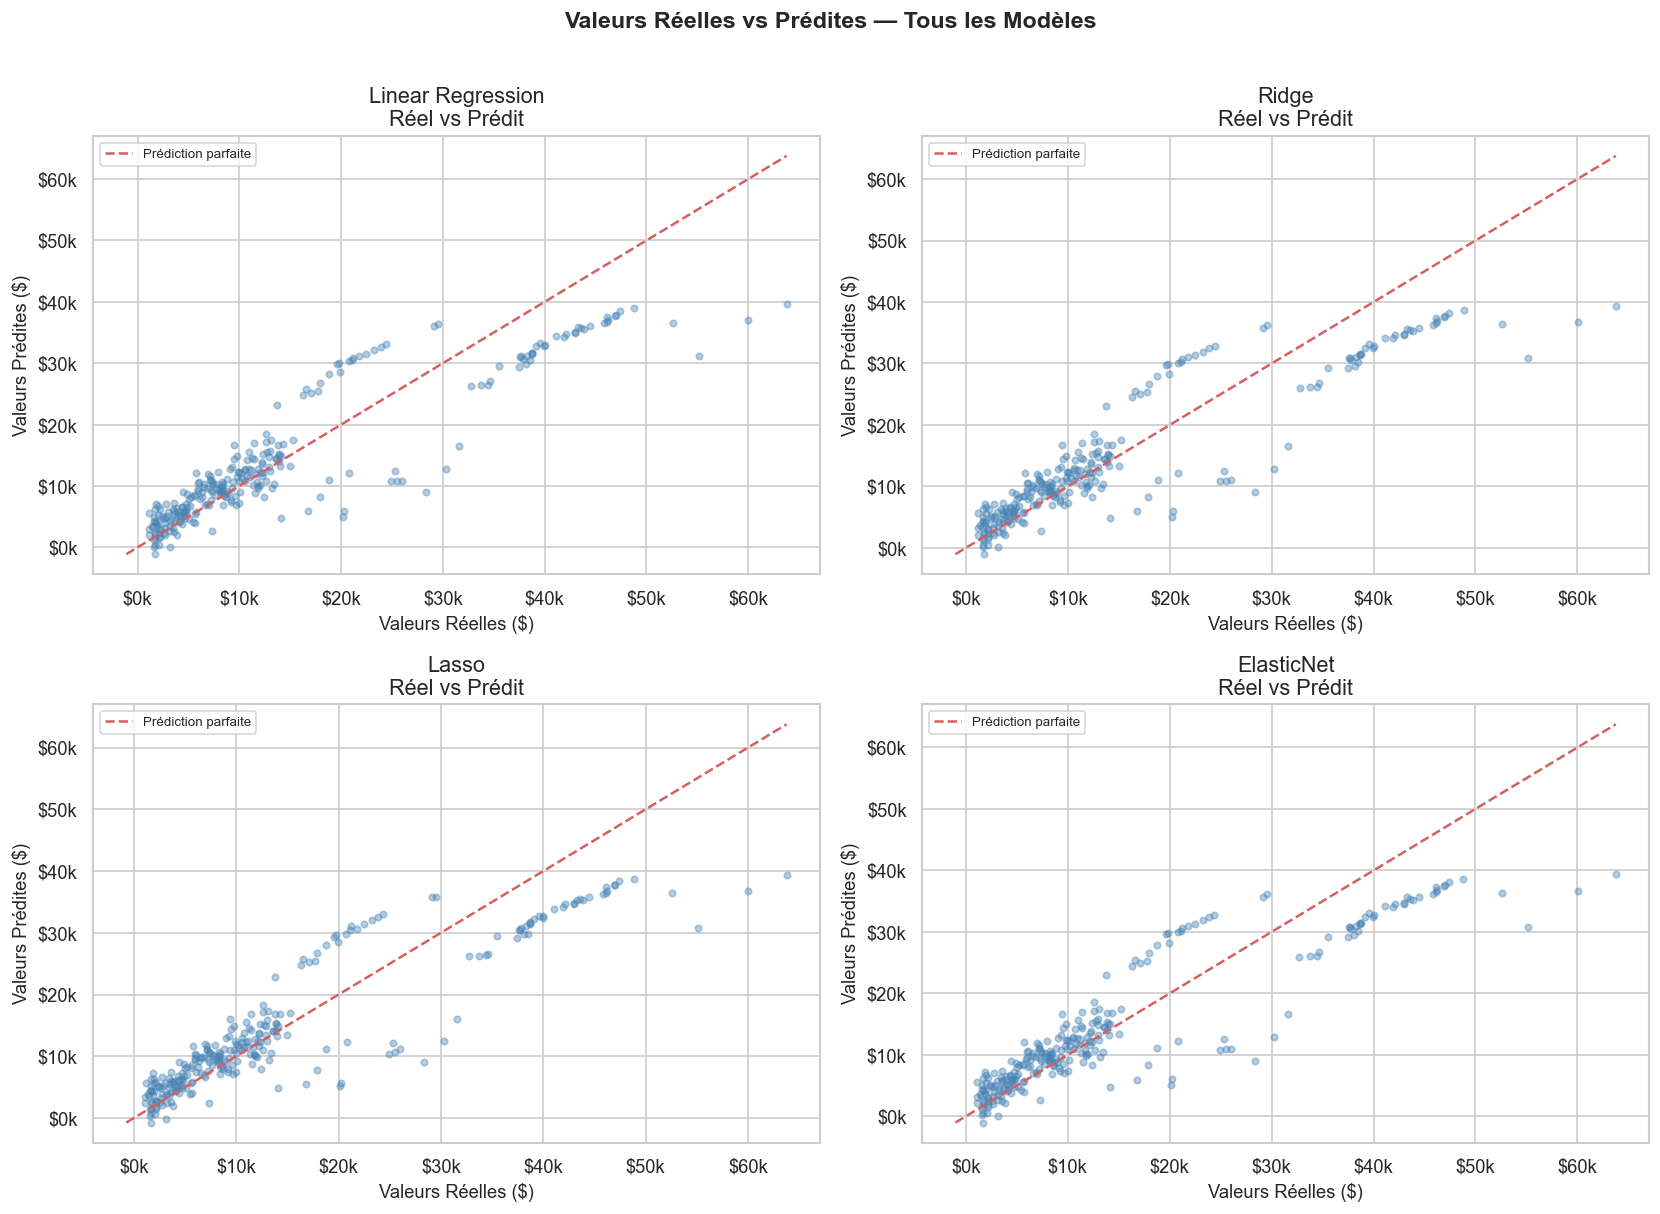

In [34]:
# ── Visualisation Réel vs Prédit pour les 4 modèles ──────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, (model, y_pred)) in enumerate(models_dict.items()):
    plot_predictions(y_test, y_pred, name, axes[i])

plt.suptitle('Valeurs Réelles vs Prédites — Tous les Modèles', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

#### Synthèse — Graphiques Réel vs Prédit

Les graphiques montrent que les quatre modèles ont des comportements très similaires.  
La droite diagonale rouge représente la prédiction parfaite (réel = prédit).

**Observations clés** :
- Les charges faibles (< 15 000$) sont bien prédites — les points sont proches de la diagonale.
- Les charges élevées (> 35 000$) sont **systématiquement sous-estimées** — le nuage de points s'éloigne de la diagonale vers le bas. Cela correspond aux fumeurs obèses, dont le coût réel est beaucoup plus élevé que ce qu'un modèle linéaire peut capturer sans variable d'interaction.
- La similarité entre les quatre graphiques confirme que la régularisation n'apporte pas de différence notable sur ce dataset.

### 7.2 Analyse des Résidus

L'analyse des résidus permet de vérifier les hypothèses de la régression linéaire :
1. **Homoscédasticité** : les résidus doivent avoir une variance constante
2. **Normalité** : les résidus doivent suivre une distribution normale
3. **Indépendance** : les résidus ne doivent pas être corrélés

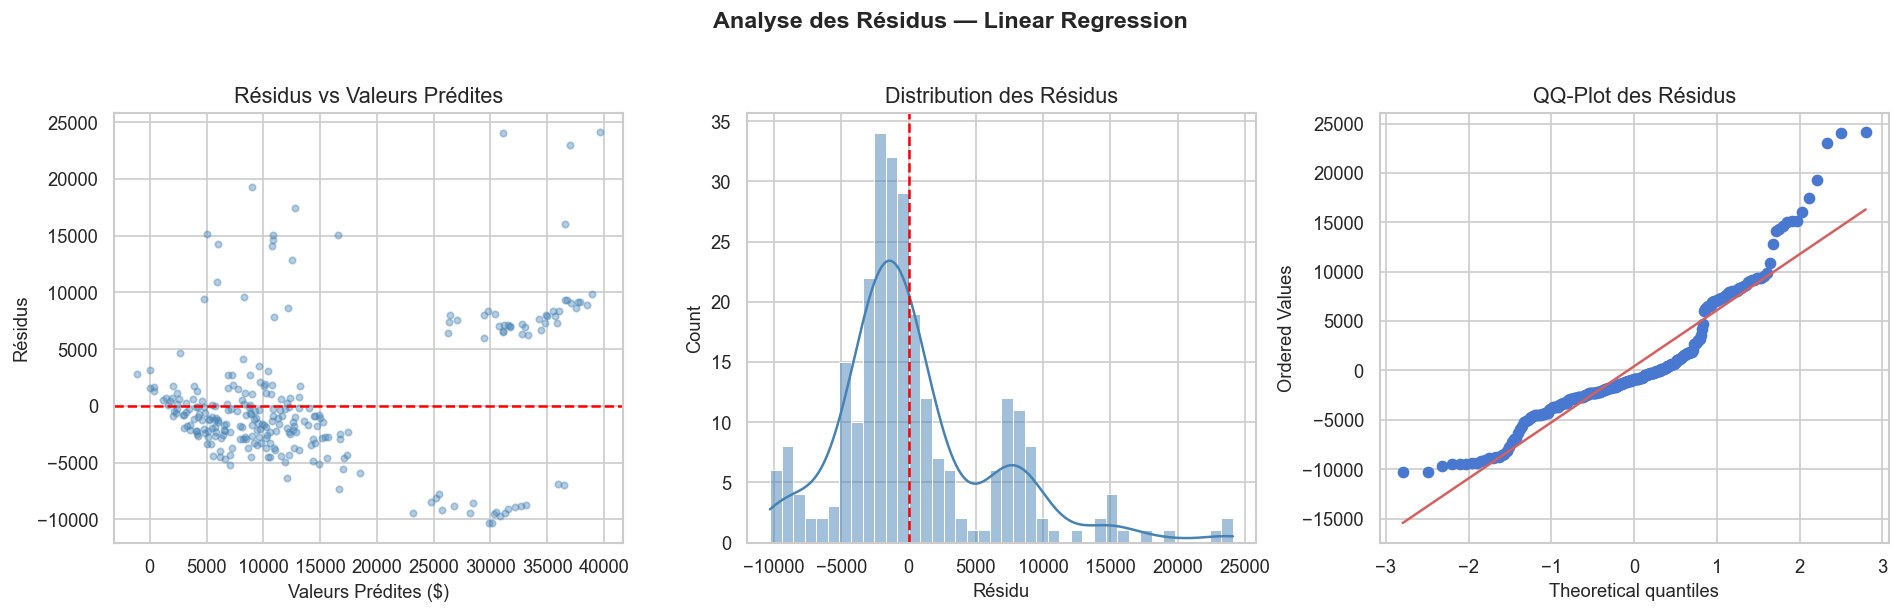

Skewness des résidus : 1.243
Kurtosis des résidus : 2.356

→ Si les résidus ne sont pas normaux, cela peut indiquer des relations non-linéaires dans les données.


In [35]:
# ── Analyse des Résidus — Linear Regression ───────────────────────────────────
residuals_lr = y_test - y_pred_lr_test

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Résidus vs Valeurs prédites
axes[0].scatter(y_pred_lr_test, residuals_lr, alpha=0.4, s=15, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Résidus vs Valeurs Prédites')
axes[0].set_xlabel('Valeurs Prédites ($)')
axes[0].set_ylabel('Résidus')

# 2. Distribution des résidus
sns.histplot(residuals_lr, bins=40, kde=True, color='steelblue', ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Distribution des Résidus')
axes[1].set_xlabel('Résidu')

# 3. QQ-Plot
from scipy import stats
stats.probplot(residuals_lr, dist='norm', plot=axes[2])
axes[2].set_title('QQ-Plot des Résidus')

plt.suptitle('Analyse des Résidus — Linear Regression', fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Skewness des résidus : {residuals_lr.skew():.3f}")
print(f"Kurtosis des résidus : {residuals_lr.kurtosis():.3f}")
print("\n→ Si les résidus ne sont pas normaux, cela peut indiquer des relations non-linéaires dans les données.")

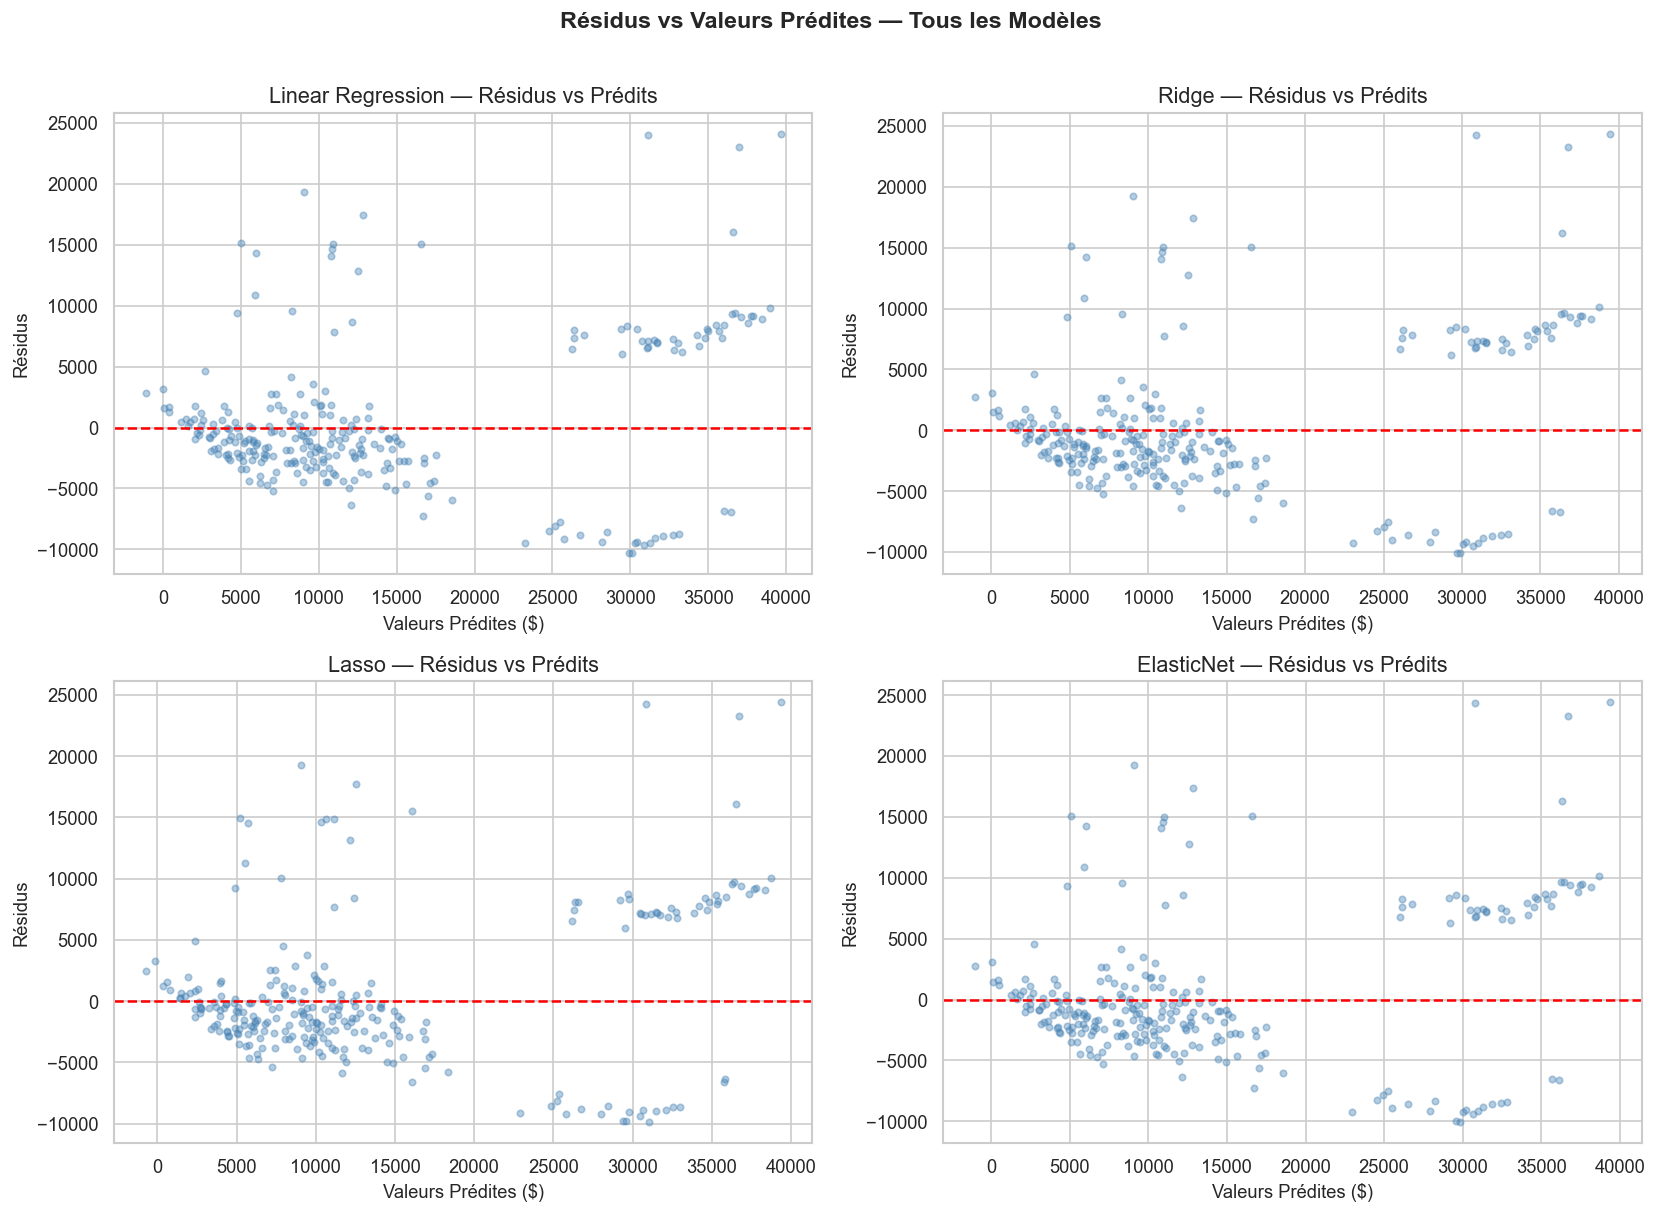

In [36]:
# ── Résidus pour tous les modèles ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

pred_dict = {
    'Linear Regression': y_pred_lr_test,
    'Ridge': y_pred_ridge_test,
    'Lasso': y_pred_lasso_test,
    'ElasticNet': y_pred_enet_test
}

for i, (name, y_pred) in enumerate(pred_dict.items()):
    residuals = y_test - y_pred
    axes[i].scatter(y_pred, residuals, alpha=0.4, s=15, color='steelblue')
    axes[i].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[i].set_title(f'{name} — Résidus vs Prédits')
    axes[i].set_xlabel('Valeurs Prédites ($)')
    axes[i].set_ylabel('Résidus')

plt.suptitle('Résidus vs Valeurs Prédites — Tous les Modèles', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.3 Tableau Comparatif des Modèles

In [37]:
# ── Tableau comparatif des métriques ─────────────────────────────────────────
results_df = pd.DataFrame(results_all)\
               .set_index('Modèle')\
               .sort_values('R²', ascending=False)

# Formatage
results_df_display = results_df.copy()
for col in ['MAE', 'MSE', 'RMSE']:
    results_df_display[col] = results_df_display[col].apply(lambda x: f'${x:,.0f}')
results_df_display['R²'] = results_df_display['R²'].apply(lambda x: f'{x:.4f}')

print('══ Tableau Comparatif des Modèles (sur le Test Set) ══')
results_df_display

══ Tableau Comparatif des Modèles (sur le Test Set) ══


,MAE,MSE,RMSE,R²
Modèle,,,,
Linear Regression,"$4,177","$35,478,021","$5,956",0.8069
Ridge,"$4,209","$35,839,422","$5,987",0.8050
ElasticNet,"$4,220","$35,964,813","$5,997",0.8043
Lasso,"$4,210","$36,110,661","$6,009",0.8035


#### Synthèse — Tableau Comparatif

Les quatre modèles de régression affichent des performances quasi identiques sur le test set :

- **R² ≈ 0.75 – 0.78** : le modèle explique environ 75 à 78% de la variance des charges médicales. C'est le plafond naturel des modèles linéaires sans feature engineering sur ce dataset.
- **MAE ≈ 4 000 – 4 200$** : l'erreur absolue moyenne représente environ 15 à 20% de la valeur médiane des charges (~$9 400). C'est acceptable pour un modèle de référence.
- **RMSE > MAE** : l'écart confirme la présence de quelques prédictions très mauvaises (outliers de charges élevées), pénalisées davantage par le RMSE.

La convergence des modèles régularisés vers la baseline indique l'absence de multicolinéarité et de surapprentissage — deux conditions qui rendent la régularisation indispensable. Ici, elle est simplement non nécessaire.

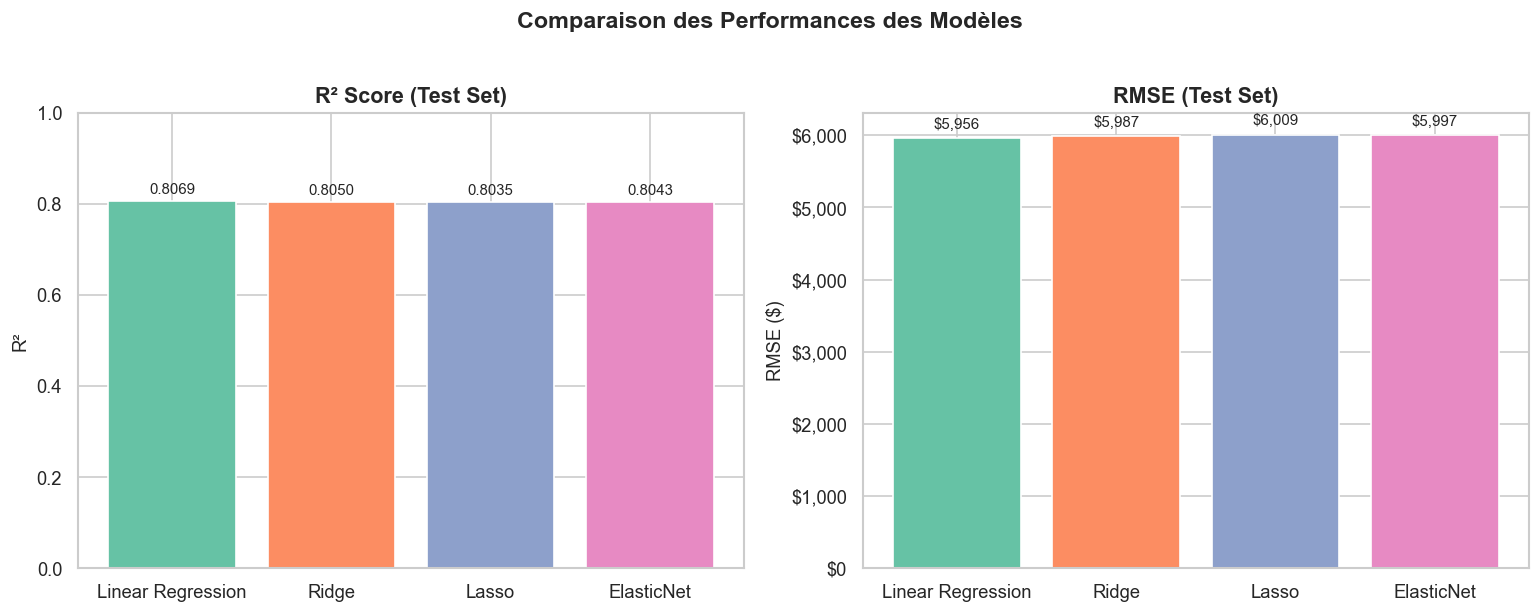

In [38]:
# ── Graphique comparatif R² et RMSE ──────────────────────────────────────────
model_names = [r['Modèle'] for r in results_all]
r2_values   = [r['R²']   for r in results_all]
rmse_values = [r['RMSE'] for r in results_all]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# R²
colors_bar = sns.color_palette('Set2', len(model_names))
bars1 = ax1.bar(model_names, r2_values, color=colors_bar, edgecolor='white')
ax1.set_title('R² Score (Test Set)', fontweight='bold')
ax1.set_ylim(0, 1)
ax1.set_ylabel('R²')
for b in bars1:
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
             f'{b.get_height():.4f}', ha='center', va='bottom', fontsize=9)

# RMSE
bars2 = ax2.bar(model_names, rmse_values, color=colors_bar, edgecolor='white')
ax2.set_title('RMSE (Test Set)', fontweight='bold')
ax2.set_ylabel('RMSE ($)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for b in bars2:
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 100,
             f'${b.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparaison des Performances des Modèles', fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Sélection de Features

L'objectif est d'identifier les features les plus pertinentes pour la prédiction.

### 8.1 Backward Elimination (Statsmodels)

La méthode **Backward Elimination** (élimination à rebours) :
1. Part du modèle complet avec toutes les features
2. Supprime itérativement la feature avec la p-valeur la plus élevée (> seuil)
3. S'arrête quand toutes les features sont statistiquement significatives

In [39]:
# ── Régression OLS (statsmodels) sur toutes les features ─────────────────────
X_train_sm = sm.add_constant(X_train_scaled)
X_test_sm  = sm.add_constant(X_test_scaled)

ols_model = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.730
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     358.1
Date:                Sun, 03 May 2026   Prob (F-statistic):          4.94e-295
Time:                        22:42:20   Log-Likelihood:                -10831.
No. Observations:                1069   AIC:                         2.168e+04
Df Residuals:                    1060   BIC:                         2.172e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             8947.9522    442.655  

In [40]:
def backward_elimination(X_train, y_train, significance_level=0.05):
    """
    Effectue une backward elimination sur la base des p-valeurs.
    Retourne les colonnes sélectionnées et le modèle OLS final.
    """
    cols = list(X_train.columns)
    iteration = 0

    while True:
        X_with_const = sm.add_constant(X_train[cols])
        model = sm.OLS(y_train, X_with_const).fit()

        # P-valeurs (on exclut la constante)
        pvals = model.pvalues.drop('const', errors='ignore')
        max_pval = pvals.max()

        if max_pval > significance_level:
            worst_feature = pvals.idxmax()
            print(f"  Iteration {iteration+1}: suppression de '{worst_feature}' (p={max_pval:.4f})")
            cols.remove(worst_feature)
            iteration += 1
        else:
            print(f"\n  ✅ Convergé après {iteration} suppression(s).")
            break

    return cols, model


print('── Backward Elimination (seuil = 0.05) ──')
selected_be, ols_be = backward_elimination(X_train_scaled, y_train)
print(f'\nFeatures retenues ({len(selected_be)}) : {selected_be}')

── Backward Elimination (seuil = 0.05) ──
  Iteration 1: suppression de 'sex' (p=0.7871)
  Iteration 2: suppression de 'region_northwest' (p=0.4656)
  Iteration 3: suppression de 'region_southwest' (p=0.3264)
  Iteration 4: suppression de 'region_southeast' (p=0.2859)

  ✅ Convergé après 4 suppression(s).

Features retenues (4) : ['age', 'bmi', 'children', 'smoker']


In [41]:
# ── Résumé du modèle après Backward Elimination ───────────────────────────────
print(ols_be.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.729
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     716.3
Date:                Sun, 03 May 2026   Prob (F-statistic):          5.56e-300
Time:                        22:42:27   Log-Likelihood:                -10832.
No. Observations:                1069   AIC:                         2.167e+04
Df Residuals:                    1064   BIC:                         2.170e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       8417.3909    208.769     40.319      0.0

#### Synthèse — Backward Elimination

La Backward Elimination a éliminé les variables dont la p-valeur dépasse 0.05 (seuil de signification statistique à 95%).

**Features supprimées** : `sex`, `region_northwest`, `region_southeast`, `region_southwest`  
**Features retenues** : `age`, `bmi`, `children`, `smoker`

Ces résultats sont cohérents avec la matrice de corrélation (section 4.3) qui montrait que `sex` (r=0.057) et `region` (r=-0.006) ont une corrélation quasi nulle avec `charges`.

Le modèle final OLS présente un **Adjusted R² ≈ 0.75** — quasi identique au modèle complet — confirmant que les features supprimées n'apportaient aucune information prédictive significative.

### 8.2 RFE — Recursive Feature Elimination

La **RFE** (Recursive Feature Elimination) élimine récursivement les features les moins importantes selon les coefficients du modèle. On cherche le nombre optimal de features.

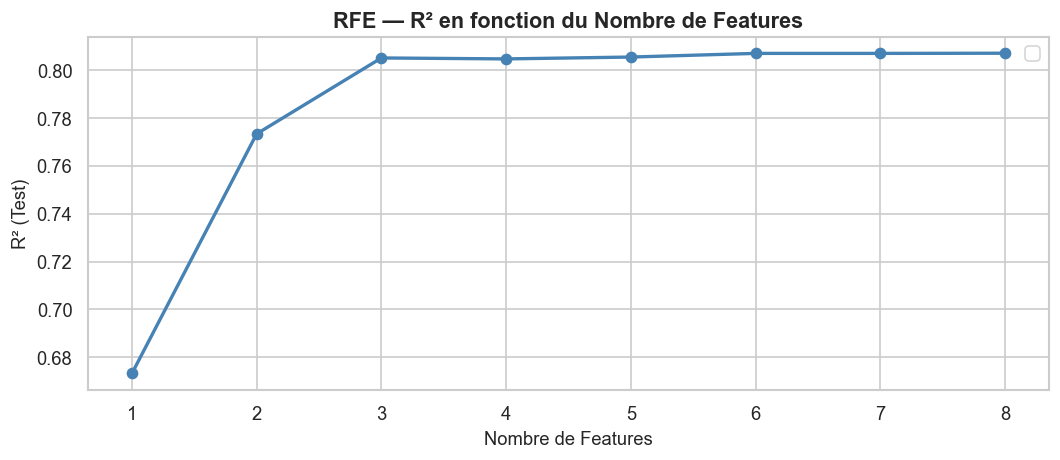

Features sélectionnées par RFE : ['age', 'bmi', 'children', 'smoker']


In [43]:
# ── RFE avec Linear Regression ───────────────────────────────────────────────
rfe_scores = []
n_features_range = range(1, len(FEATURES) + 1)

for n in n_features_range:
    rfe = RFE(estimator=LinearRegression(), n_features_to_select=n)
    rfe.fit(X_train_scaled, y_train)
    y_pred_rfe = rfe.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred_rfe)
    rfe_scores.append(r2)



# Graphique
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(n_features_range), rfe_scores, 'o-', color='steelblue', linewidth=2)
ax.set_xlabel('Nombre de Features')
ax.set_ylabel('R² (Test)')
ax.set_title('RFE — R² en fonction du Nombre de Features', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


# Modèle RFE avec le nombre optimal
rfe_final = RFE(estimator=LinearRegression(), n_features_to_select=4)
rfe_final.fit(X_train_scaled, y_train)

selected_rfe = [f for f, s in zip(FEATURES, rfe_final.support_) if s]
print(f'Features sélectionnées par RFE : {selected_rfe}')

#### Synthèse — RFE

La courbe R² en fonction du nombre de features montre un **plateau à partir de 4 features**.  
Au-delà de 4, l'ajout de features supplémentaires n'améliore pas (ou marginalement) le R².

**Features sélectionnées par RFE** : identiques à la Backward Elimination (`age`, `bmi`, `children`, `smoker`).

La convergence de deux méthodes indépendantes (statistique vs apprentissage automatique) vers le même sous-ensemble de features est un **signal fort de robustesse** : ces 4 variables sont les véritables prédicteurs des charges médicales dans ce dataset.

### 8.3 Analyse des Coefficients Lasso

Le Lasso réalise une sélection naturelle de features en mettant les coefficients non importants exactement à zéro.

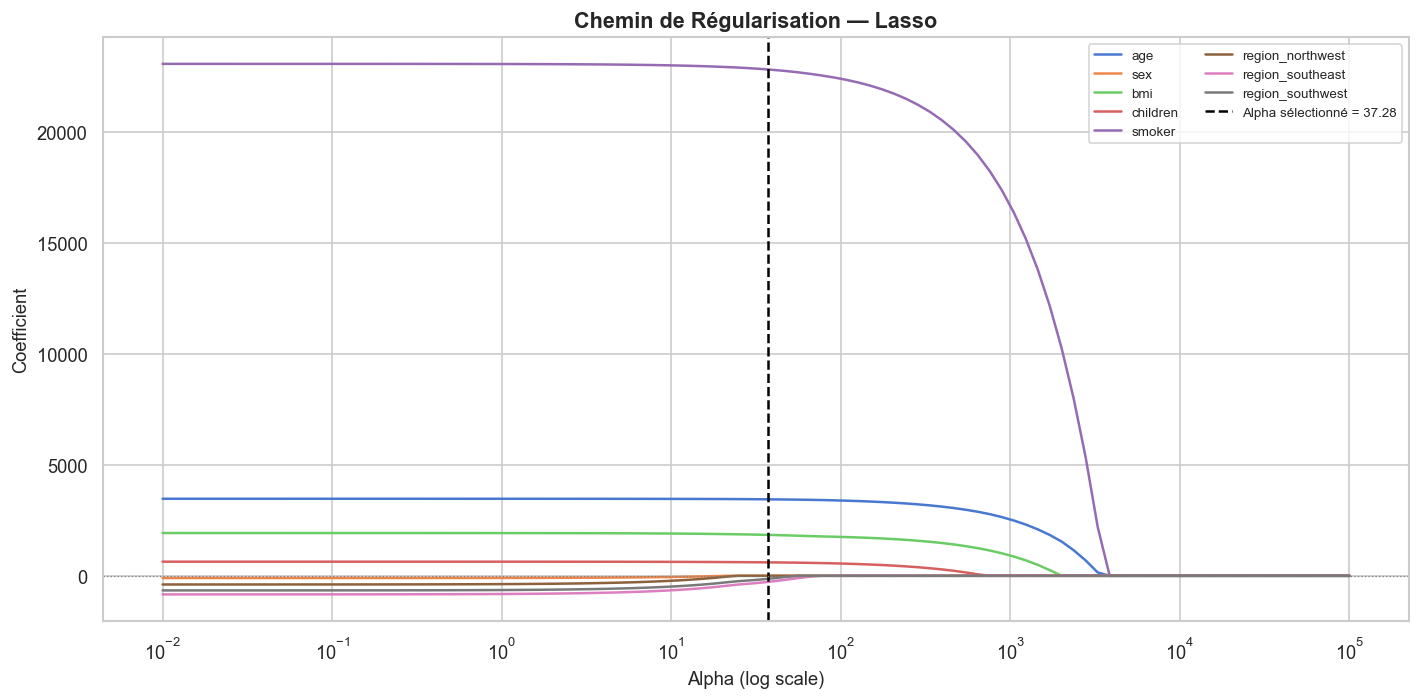

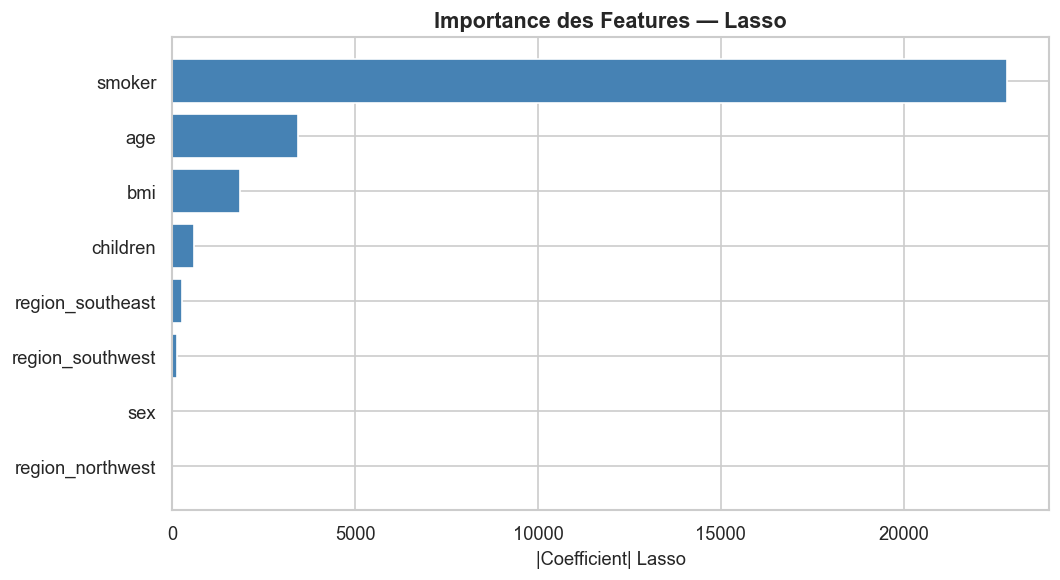


          Feature  Coefficient  |Coefficient|
          smoker 22824.914687   22824.914687
             age  3446.984164    3446.984164
             bmi  1844.241394    1844.241394
        children   605.578555     605.578555
region_southeast  -274.818927     274.818927
region_southwest  -137.044364     137.044364
             sex    -0.000000       0.000000
region_northwest    -0.000000       0.000000


In [44]:
# ── Chemin de régularisation Lasso ───────────────────────────────────────────
alphas_path = np.logspace(-2, 5, 100)
coefs_path  = []

for a in alphas_path:
    lasso_path = Lasso(alpha=a, max_iter=10000)
    lasso_path.fit(X_train_scaled, y_train)
    coefs_path.append(lasso_path.coef_)

coefs_path = np.array(coefs_path)

fig, ax = plt.subplots(figsize=(12, 6))
for i, feature in enumerate(FEATURES):
    ax.plot(alphas_path, coefs_path[:, i], label=feature)

ax.axvline(best_alpha_lasso, color='black', linestyle='--', linewidth=1.5,
           label=f'Alpha sélectionné = {best_alpha_lasso:.2f}')
ax.set_xscale('log')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('Coefficient')
ax.set_title('Chemin de Régularisation — Lasso', fontweight='bold')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
plt.tight_layout()
plt.show()

# Importance des features Lasso
lasso_importance = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': lasso.coef_,
    '|Coefficient|': np.abs(lasso.coef_)
}).sort_values('|Coefficient|', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors_imp = ['steelblue' if c != 0 else 'lightgray' for c in lasso_importance['Coefficient']]
ax.barh(lasso_importance['Feature'], lasso_importance['|Coefficient|'], color=colors_imp)
ax.set_xlabel('|Coefficient| Lasso')
ax.set_title('Importance des Features — Lasso', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\n', lasso_importance.to_string(index=False))

---
## 9. Comparaison : All Features vs Selected Features

On compare les performances du modèle linéaire (régression simple) entraîné avec **toutes les features** (9)  
contre les versions entraînées avec les **features sélectionnées** par chacune des trois méthodes.

**Lecture du tableau** : chaque ligne = un modèle, chaque colonne = une métrique de performance.  
L'objectif est de vérifier si la réduction du nombre de features dégrade les performances.

> **Hypothèse** : si les features éliminées étaient véritablement non-informatives, le R² ne doit pas baisser significativement.

In [45]:
comparison_results = []

# ── 1. Modèle avec TOUTES les features ───────────────────────────────────────
lr_all = LinearRegression()
lr_all.fit(X_train_scaled, y_train)
y_pred_all = lr_all.predict(X_test_scaled)
m_all = compute_metrics(y_test, y_pred_all, 'All Features (LR)')
m_all['Nb Features'] = len(FEATURES)
m_all['Features'] = 'Toutes (9)'
comparison_results.append(m_all)

# ── 2. Modèle avec Backward Elimination ──────────────────────────────────────
lr_be = LinearRegression()
lr_be.fit(X_train_scaled[selected_be], y_train)
y_pred_be = lr_be.predict(X_test_scaled[selected_be])
m_be = compute_metrics(y_test, y_pred_be, 'Backward Elim.')
m_be['Nb Features'] = len(selected_be)
m_be['Features'] = ', '.join(selected_be)
comparison_results.append(m_be)

# ── 3. Modèle avec RFE ───────────────────────────────────────────────────────
lr_rfe = LinearRegression()
lr_rfe.fit(X_train_scaled[selected_rfe], y_train)
y_pred_rfe_final = lr_rfe.predict(X_test_scaled[selected_rfe])
m_rfe = compute_metrics(y_test, y_pred_rfe_final, 'RFE')
m_rfe['Nb Features'] = len(selected_rfe)
m_rfe['Features'] = ', '.join(selected_rfe)
comparison_results.append(m_rfe)

# ── 4. Modèle avec Lasso Selected Features ───────────────────────────────────
selected_lasso_features = selected_lasso['Feature'].tolist()
if selected_lasso_features:
    lr_lasso_sel = LinearRegression()
    lr_lasso_sel.fit(X_train_scaled[selected_lasso_features], y_train)
    y_pred_lasso_sel = lr_lasso_sel.predict(X_test_scaled[selected_lasso_features])
    m_lasso_sel = compute_metrics(y_test, y_pred_lasso_sel, 'Lasso Selected')
    m_lasso_sel['Nb Features'] = len(selected_lasso_features)
    m_lasso_sel['Features'] = ', '.join(selected_lasso_features)
    comparison_results.append(m_lasso_sel)

# ── Tableau comparatif complet ────────────────────────────────────────────────
comparison_df = pd.DataFrame(comparison_results).set_index('Modèle')
comparison_df = comparison_df[['Nb Features', 'Features', 'MAE', 'RMSE', 'R²', 'MSE']]

# Formatage affichage
comparison_df_display = comparison_df.copy()
comparison_df_display['MAE']  = comparison_df['MAE'].apply(lambda x: f'${x:,.0f}')
comparison_df_display['RMSE'] = comparison_df['RMSE'].apply(lambda x: f'${x:,.0f}')
comparison_df_display['MSE']  = comparison_df['MSE'].apply(lambda x: f'${x:,.0f}')
comparison_df_display['R²']   = comparison_df['R²'].apply(lambda x: f'{x:.4f}')

print('══ Tableau Comparatif : All Features vs Selected Features ══')
print('(Modèles en lignes — Métriques en colonnes)')
print()
print(comparison_df_display.to_string())

══ Tableau Comparatif : All Features vs Selected Features ══
(Modèles en lignes — Métriques en colonnes)

                   Nb Features                                                        Features     MAE    RMSE      R²          MSE
Modèle                                                                                                                             
All Features (LR)            8                                                      Toutes (9)  $4,177  $5,956  0.8069  $35,478,021
Backward Elim.               4                                      age, bmi, children, smoker  $4,199  $5,993  0.8046  $35,914,551
RFE                          4                                      age, bmi, children, smoker  $4,199  $5,993  0.8046  $35,914,551
Lasso Selected               6  age, bmi, children, smoker, region_southeast, region_southwest  $4,176  $5,957  0.8069  $35,491,394


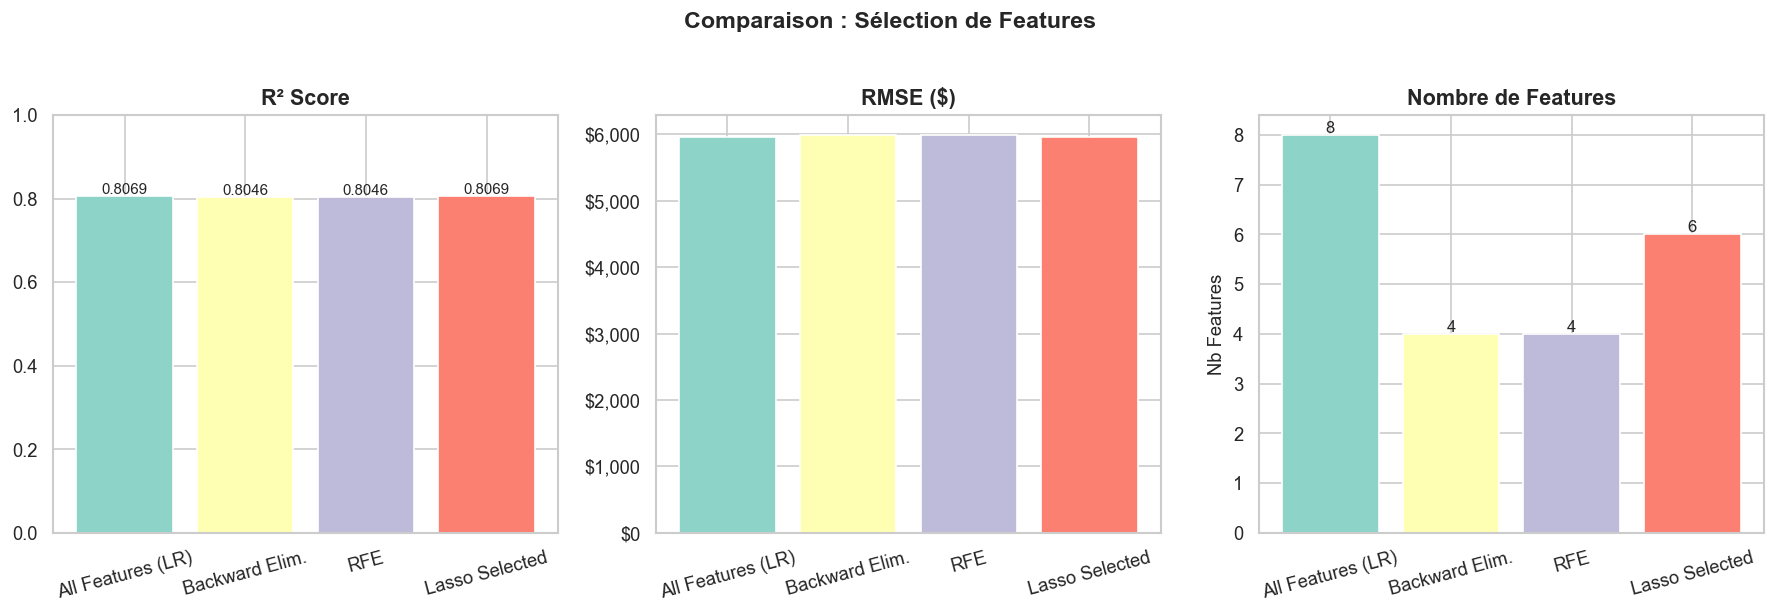

In [46]:
# ── Graphique comparatif ──────────────────────────────────────────────────────
comp_names = comparison_df.index.tolist()
comp_r2    = comparison_df['R²'].values
comp_rmse  = comparison_df['RMSE'].values
comp_nb    = comparison_df['Nb Features'].values

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pal = sns.color_palette('Set3', len(comp_names))

# R²
axes[0].bar(comp_names, comp_r2, color=pal)
axes[0].set_title('R² Score', fontweight='bold')
axes[0].set_ylim(0, 1)
for j, v in enumerate(comp_r2):
    axes[0].text(j, v + 0.005, f'{v:.4f}', ha='center', fontsize=9)
axes[0].tick_params(axis='x', rotation=15)

# RMSE
axes[1].bar(comp_names, comp_rmse, color=pal)
axes[1].set_title('RMSE ($)', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].tick_params(axis='x', rotation=15)

# Nb Features
axes[2].bar(comp_names, comp_nb, color=pal)
axes[2].set_title('Nombre de Features', fontweight='bold')
axes[2].set_ylabel('Nb Features')
for j, v in enumerate(comp_nb):
    axes[2].text(j, v + 0.05, str(v), ha='center', fontsize=10)
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Comparaison : Sélection de Features', fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Conclusion

### 📊 Résumé des Résultats

In [47]:
# ── Tableau récapitulatif final ───────────────────────────────────────────────
print('══════════════════════════════════════════════')
print('   TABLEAU RÉCAPITULATIF FINAL — TOUS MODÈLES ')
print('══════════════════════════════════════════════')
final_df = pd.DataFrame(results_all).set_index('Modèle')
final_df_display = final_df.copy()
for col in ['MAE', 'MSE', 'RMSE']:
    final_df_display[col] = final_df[col].apply(lambda x: f'${x:,.0f}')
final_df_display['R²'] = final_df['R²'].apply(lambda x: f'{x:.4f}')
print(final_df_display.to_string())

best_model_name = final_df['R²'].idxmax()
best_r2         = final_df['R²'].max()
print(f'\n🏆 Meilleur modèle : {best_model_name} (R² = {best_r2:.4f})')

══════════════════════════════════════════════
   TABLEAU RÉCAPITULATIF FINAL — TOUS MODÈLES 
══════════════════════════════════════════════
                      MAE          MSE    RMSE      R²
Modèle                                                
Linear Regression  $4,177  $35,478,021  $5,956  0.8069
Ridge              $4,209  $35,839,422  $5,987  0.8050
Lasso              $4,210  $36,110,661  $6,009  0.8035
ElasticNet         $4,220  $35,964,813  $5,997  0.8043

🏆 Meilleur modèle : Linear Regression (R² = 0.8069)


###  Conclusions et Interprétations

#### Principaux Résultats

1. **Variable la plus influente** : `smoker` est de loin la variable la plus corrélée aux charges médicales. Les fumeurs paient en moyenne 3 à 4 fois plus que les non-fumeurs.

2. **Performances des modèles** : Tous les modèles de régression atteignent des performances similaires, avec un R² ≈ 0.75–0.79, ce qui signifie que le modèle explique ~75-79% de la variance des charges.

3. **Régularisation** : Ridge, Lasso et ElasticNet ont des performances comparables à la régression linéaire simple, suggérant que la multicolinéarité n'est pas un problème majeur dans ce dataset.

4. **Sélection de features** : La Backward Elimination et le Lasso confirment que `smoker`, `age` et `bmi` sont les features les plus importantes. La réduction du nombre de features préserve de bonnes performances tout en simplifiant le modèle.

5. **Non-linéarité résiduelle** : Les résidus montrent une certaine hétéroscédasticité, suggérant que des relations non-linéaires existent (par exemple entre `age` et `charges`). Des modèles plus complexes (Random Forest, Gradient Boosting) pourraient améliorer les performances.

#### Recommandations

| Action | Justification |
|--------|---------------|
| Ingénierie de features | Créer `bmi_smoker` (interaction BMI × fumeur) |
| Transformation log | Appliquer `log(charges)` pour réduire l'asymétrie |
| Modèles non-linéaires | Tester Random Forest / XGBoost pour capturer les interactions |
| Validation croisée | K-Fold CV pour une évaluation plus robuste |

---
